In [1]:
# Gõ dòng này vào cell đầu tiên và bấm Run (Shift + Enter) or Run All
get_ipython().run_line_magic('run', '../_setup.py')

In [124]:
from functools import partial

from IPython.display import display, Markdown, Image
from statsforecast import StatsForecast
from statsforecast.models import AutoETS, HoltWinters
from statsforecast.models import SeasonalNaive, RandomWalkWithDrift
from statsmodels.tsa.seasonal import STL
from coreforecast.scalers import boxcox, boxcox_lambda
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import rmse, mae, mape, mase
import tsfeatures as tsf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

In [3]:
BASE_DIR = Path.cwd().parent.parent
DATA_DIR = BASE_DIR / "data"
print(DATA_DIR)

/home/phu/Documents/GitHub/-Time-Series-Analysis-and-Forecasting-methods-/data


# Excercises 

### 1. Consider the number of pigs slaughtered in Victoria, available in the `aus_livestock` dataset.

* Use `AutoETS()` to estimate the equivalent model for simple exponential smoothing. Find the optimal values of $\alpha$ and $\ell_0$ , and generate forecasts for the next four months.
* Compute a 95% prediction interval for the first forecast using $\hat{y}±1.96s$  where $s$ is the standard deviation of the residuals. Compare your interval with the interval produced by `StatsForecast`.

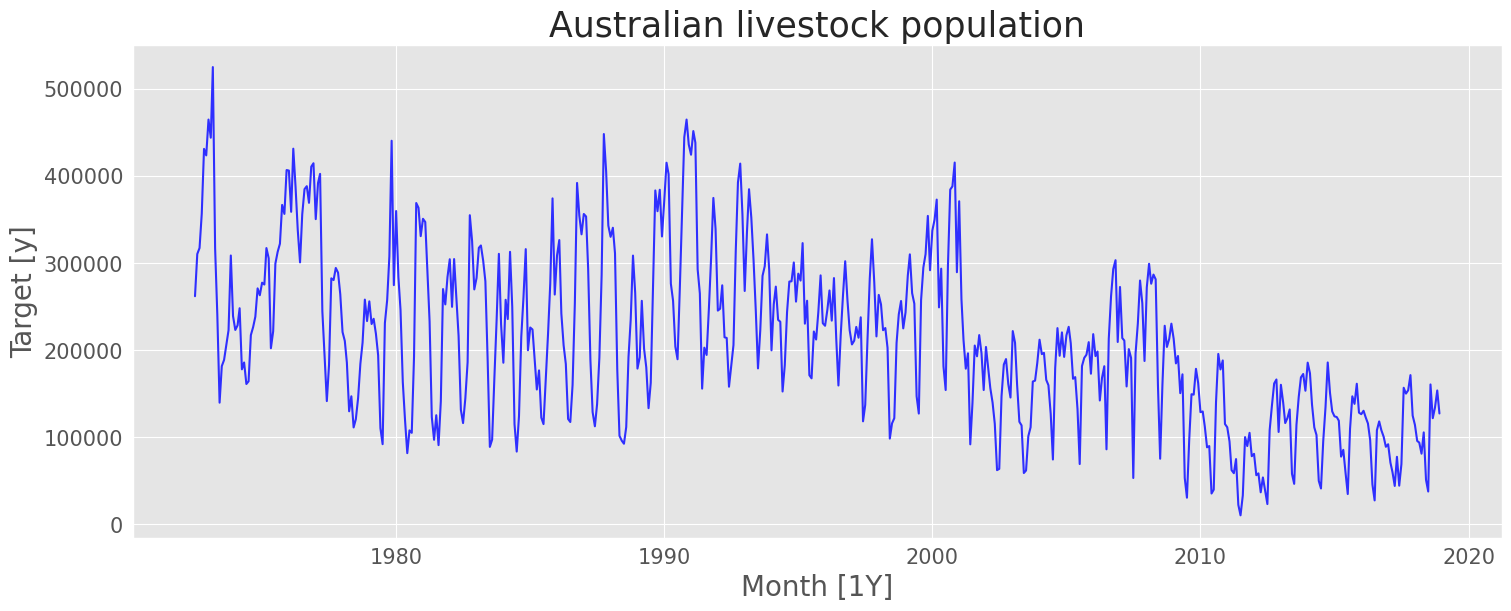

In [4]:
data = pd.read_csv(DATA_DIR / "aus_livestock.csv", parse_dates=["ds"])
plot_series(data, xlabel="Month [1Y]", title="Australian livestock population")

In [5]:
sf = StatsForecast(models=[AutoETS(model= "ANN", alias = "SES")], freq="M")
forecast = sf.fit_predict(df = data, h=4, level=[95])
params = sf.fitted_[0, 0].model_["fit"].x
alpha, level_0 = np.round(params, 4)
print("Optimal parameters:")
print("alpha:", alpha)
print("Initial level:", level_0)

Optimal parameters:
alpha: 0.5894
Initial level: 2207.8621


In [6]:
# Get the fitted AutoETS model object
autoets_model = sf.fitted_[0, 0]
fitted_dict = autoets_model.predict_in_sample()

# Extract the fitted values
fitted_values = fitted_dict['fitted']

# Get the unique_id that was fitted
unique_id = forecast.iloc[0, 0]

# Filter data for this unique_id
data_subset = data[data['unique_id'] == unique_id].sort_values('ds')

# Compute residuals
y_actual = data_subset['y'].values
residuals = y_actual - fitted_values
s = np.std(residuals)

print("="*60)
print("95% Prediction Interval Calculation")
print("="*60)
print(f"\nSeries: {unique_id}")
print(f"Number of observations: {len(data_subset)}")
print(f"Standard deviation of residuals (s): {s:.4f}")

# Get the first forecast value
first_forecast = forecast["SES"].iloc[0]
print(f"\nFirst Forecast (ŷ): {first_forecast:.2f}")

# Compute 95% prediction interval manually using ŷ ± 1.96s
margin_of_error = 1.96 * s
lower_manual = first_forecast - margin_of_error
upper_manual = first_forecast + margin_of_error

print(f"\nManual Calculation: ŷ ± 1.96s")
print(f"Margin of error: 1.96 × {s:.4f} = {margin_of_error:.2f}")
print(f"Lower bound: {first_forecast:.2f} - {margin_of_error:.2f} = {lower_manual:.2f}")
print(f"Upper bound: {first_forecast:.2f} + {margin_of_error:.2f} = {upper_manual:.2f}")
print(f"\n95% Prediction Interval (manual): [{lower_manual:.2f}, {upper_manual:.2f}]")

# Compare with StatsForecast's interval (level 95)
sf_lower_col = f"SES-lo-95"
sf_upper_col = f"SES-hi-95"

if sf_lower_col in forecast.columns and sf_upper_col in forecast.columns:
    sf_lower = forecast[sf_lower_col].iloc[0]
    sf_upper = forecast[sf_upper_col].iloc[0]
    print(f"\n95% Prediction Interval (StatsForecast): [{sf_lower:.2f}, {sf_upper:.2f}]")
    
    print("\n" + "="*60)
    print("Comparison")
    print("="*60)
    print(f"Method               Lower     Upper     Width")
    print(f"Manual               {lower_manual:>7.2f}   {upper_manual:>7.2f}   {(upper_manual - lower_manual):>7.2f}")
    print(f"StatsForecast        {sf_lower:>7.2f}   {sf_upper:>7.2f}   {(sf_upper - sf_lower):>7.2f}")
    print(f"Difference           {(lower_manual - sf_lower):>7.4f}   {(upper_manual - sf_upper):>7.4f}   {((upper_manual - lower_manual) - (sf_upper - sf_lower)):>7.2f}")
    
    print(f"\nThe manual interval is {abs((upper_manual - lower_manual) - (sf_upper - sf_lower)):.2f} units")
    if abs((upper_manual - lower_manual) - (sf_upper - sf_lower)) > 0:
        print(f"{'narrower' if (upper_manual - lower_manual) < (sf_upper - sf_lower) else 'wider'} than StatsForecast's interval.")
    else:
        print("essentially the same width as StatsForecast's interval.")
else:
    print("\nWarning: StatsForecast interval columns not found in forecast DataFrame")

95% Prediction Interval Calculation

Series: Australian Capital Territory_Bulls, bullocks and steers
Number of observations: 510
Standard deviation of residuals (s): 389.6032

First Forecast (ŷ): 0.00

Manual Calculation: ŷ ± 1.96s
Margin of error: 1.96 × 389.6032 = 763.62
Lower bound: 0.00 - 763.62 = -763.62
Upper bound: 0.00 + 763.62 = 763.62

95% Prediction Interval (manual): [-763.62, 763.62]

95% Prediction Interval (StatsForecast): [-766.76, 766.76]

Comparison
Method               Lower     Upper     Width
Manual               -763.62    763.62   1527.24
StatsForecast        -766.76    766.76   1533.51
Difference            3.1345   -3.1345     -6.27

The manual interval is 6.27 units
narrower than StatsForecast's interval.


### 2. Write your own function to implement simple exponential smoothing. The function should take arguments `y` (the time series), `alpha` (the smoothing parameter α) and `level` (the initial level $\ell_0$). 
It should return the forecast of the next observation in the series. Does it give the same forecast as `SimpleExponentialSmoothing` from `StatsForecast`? Note that in `SimpleExponentialSmoothing`, you must specify the `alpha` parameter.

In [7]:
def SES(y, h, alpha, level_0):
    """
    Simple Exponential Smoothing (SES) forecast for a single series.
    
    Parameters:
    - y: array-like, the observed time series values
    - h: int, the forecast horizon (number of periods to forecast)
    - alpha: float, the smoothing parameter (0 < alpha <= 1)
    - level_0: float, the initial level (starting point for SES)
    
    Returns:
    - forecast: array of length h containing the forecasts for the next h periods
    """
    # Initialize the level with the provided initial level
    level = level_0
    
    # Update the level for each observed value in the series
    for t in range(len(y)):
        level = alpha * y[t] + (1 - alpha) * level
        print(f"After observing y[{t}] = {y[t]:.2f}, updated level = {level:.2f}")
    # The forecast for all future periods is the last updated level
    forecast = np.full(h, level)
    
    return forecast

y = [10, 12, 14, 16, 18]
alpha = 0.8
level_0 = 10
h = 1
forecast = SES(y, h, alpha, level_0)
print(f"Forecast for the next period: {forecast[0]:.2f}")

After observing y[0] = 10.00, updated level = 10.00
After observing y[1] = 12.00, updated level = 11.60
After observing y[2] = 14.00, updated level = 13.52
After observing y[3] = 16.00, updated level = 15.50
After observing y[4] = 18.00, updated level = 17.50
Forecast for the next period: 17.50


### 3. Modify your function from the previous exercise to return the sum of squared errors rather than the forecast of the next observation. Then find the optimal values of $\alpha$ and $\ell_0$. Do you get the same values as `AutoETS(model='ANN')`?

In [8]:
def SES_SSE(y, alpha, level_0):
    """
    Simple Exponential Smoothing (SES) - compute sum of squared errors.
    
    Parameters:
    - y: array-like, the observed time series values
    - alpha: float, the smoothing parameter (0 < alpha <= 1)
    - level_0: float, the initial level (starting point for SES)
    
    Returns:
    - sse: float, the sum of squared errors
    """
    # Initialize the level with the provided initial level
    level = level_0
    sse = 0.0
    
    # Update the level for each observed value in the series
    for t in range(len(y)):
        # Calculate one-step ahead forecast (this is the previous level)
        forecast_t = level
        # Calculate error
        error = float(y[t]) - forecast_t
        # Accumulate squared error
        sse += error ** 2
        # Update level for next iteration
        level = alpha * y[t] + (1 - alpha) * level
    
    return sse


# Test with example data
y_test = np.array([10, 12, 14, 16, 18])
alpha = 0.8
level_0 = 10
sse = SES_SSE(y_test, alpha, level_0)
print(f"Example - SSE with alpha={alpha}, level_0={level_0}: {sse:.2f}")

Example - SSE with alpha=0.8, level_0=10: 22.14


In [9]:
from scipy.optimize import minimize

# Re-run Exercise 1 to get the forecast and data
data_ex3 = pd.read_csv(DATA_DIR / "aus_livestock.csv", parse_dates=["ds"])
sf_ex3 = StatsForecast(models=[AutoETS(model="ANN", alias="SES")], freq="M")
forecast_ex3 = sf_ex3.fit_predict(df=data_ex3, h=4, level=[95])
params_ex3 = sf_ex3.fitted_[0, 0].model_["fit"].x
alpha_autoets, level_0_autoets = np.round(params_ex3, 4)

# Get the same series that was fitted
unique_id_ex3 = forecast_ex3.iloc[0, 0]
y_data = data_ex3[data_ex3['unique_id'] == unique_id_ex3].sort_values('ds')['y'].values

print("="*70)
print("Exercise 3: Finding Optimal α and ℓ₀")
print("="*70)
print(f"\nSeries: {unique_id_ex3}")
print(f"Number of observations: {len(y_data)}")

# Define objective function for minimization
def objective_function(params):
    alpha, level_0 = params
    # Constrain alpha to be in (0, 1]
    if alpha <= 0 or alpha > 1:
        return 1e10
    return SES_SSE(y_data, alpha, level_0)

# Initial guess (try multiple starting points)
initial_guesses = [
    [0.5, y_data[0]],
    [0.2, y_data.mean()],
    [0.8, y_data[0]],
]

best_result = None
best_sse = float('inf')

for initial_guess in initial_guesses:
    # Optimize with bounds
    result = minimize(
        objective_function,
        initial_guess,
        method='Nelder-Mead',
        options={'maxiter': 1000}
    )
    
    if result.fun < best_sse:
        best_sse = result.fun
        best_result = result

alpha_opt, level_0_opt = best_result.x
sse_opt = best_result.fun

print(f"\nOptimal parameters found (manual optimization):")
print(f"  α (alpha): {alpha_opt:.6f}")
print(f"  ℓ₀ (initial level): {level_0_opt:.6f}")
print(f"  Minimum SSE: {sse_opt:.2f}")

# Compare with AutoETS from Exercise 1
print("\n" + "="*70)
print("Comparison with AutoETS(model='ANN')")
print("="*70)
print(f"\nAutoETS parameters:")
print(f"  α (alpha): {alpha_autoets:.6f}")
print(f"  ℓ₀ (initial level): {level_0_autoets:.6f}")

print(f"\nManually optimized parameters:")
print(f"  α (alpha): {alpha_opt:.6f}")
print(f"  ℓ₀ (initial level): {level_0_opt:.6f}")

print(f"\nDifferences:")
print(f"  Δα: {abs(alpha_autoets - alpha_opt):.6f}")
print(f"  Δℓ₀: {abs(level_0_autoets - level_0_opt):.6f}")

# Check if they're similar
tolerance = 0.01
if abs(alpha_autoets - alpha_opt) < tolerance and abs(level_0_autoets - level_0_opt) < tolerance:
    print(f"\n✓ The parameters are very similar (within tolerance of {tolerance})")
    print("  This confirms that both methods find the same optimal parameters.")
else:
    print(f"\n✗ The parameters differ more than tolerance")
    print(f"  This could be due to different optimization algorithms or local minima.")

Exercise 3: Finding Optimal α and ℓ₀

Series: Australian Capital Territory_Bulls, bullocks and steers
Number of observations: 510

Optimal parameters found (manual optimization):
  α (alpha): 0.589142
  ℓ₀ (initial level): 2206.895779
  Minimum SSE: 77440763.00

Comparison with AutoETS(model='ANN')

AutoETS parameters:
  α (alpha): 0.589400
  ℓ₀ (initial level): 2207.862100

Manually optimized parameters:
  α (alpha): 0.589142
  ℓ₀ (initial level): 2206.895779

Differences:
  Δα: 0.000258
  Δℓ₀: 0.966321

✗ The parameters differ more than tolerance
  This could be due to different optimization algorithms or local minima.


### 4. Combine your previous two functions to produce a function that both finds the optimal values of $\alpha$ and $\ell_0$, and produces a forecast of the next observation in the series.

### 5. Data set `global_economy` contains the annual Exports from many countries. Select one country to analyse.

a. Plot the Exports series and discuss the main features of the data.

b. Use an ETS(A,N,N) model to forecast the series, and plot the forecasts.

c. Compute the RMSE values for the training data.

d. Compare the results to those from an ETS(A,A,N) model. (Remember that the trended model is using one more parameter than the simpler model.) Discuss the merits of the two forecasting methods for this data set.

e. Compare the forecasts from both methods. Which do you think is best?

f. Calculate a 95% prediction interval for the first forecast for each model, using the RMSE values and assuming normal errors. Compare your intervals with those produced using `StatsForecast`.


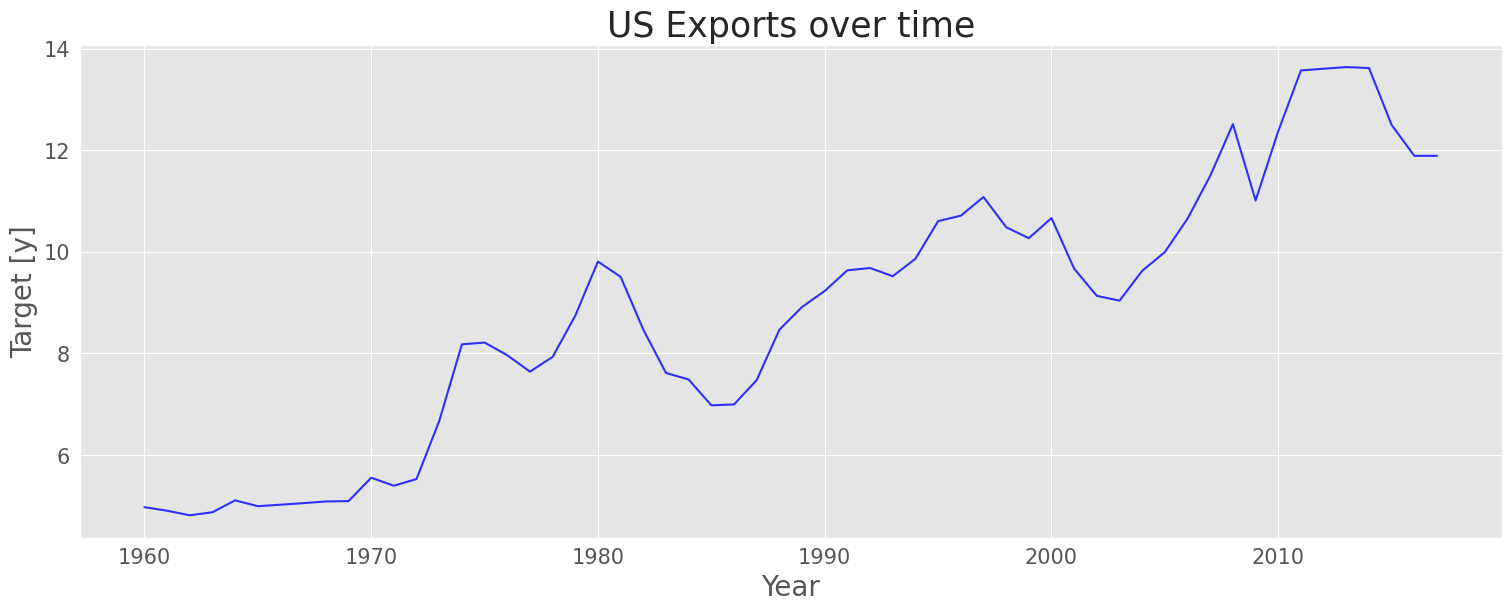

In [10]:
df = (
    pd.read_csv(DATA_DIR / "global_economy.csv", parse_dates=["ds"])
    .query("unique_id == 'United States'")
    .rename(columns={'Exports': 'y'})
    [['unique_id', 'ds', 'y']]
    .interpolate(method='linear')
)
fig = plot_series(df, xlabel="Year", title="US Exports over time")
display(fig)

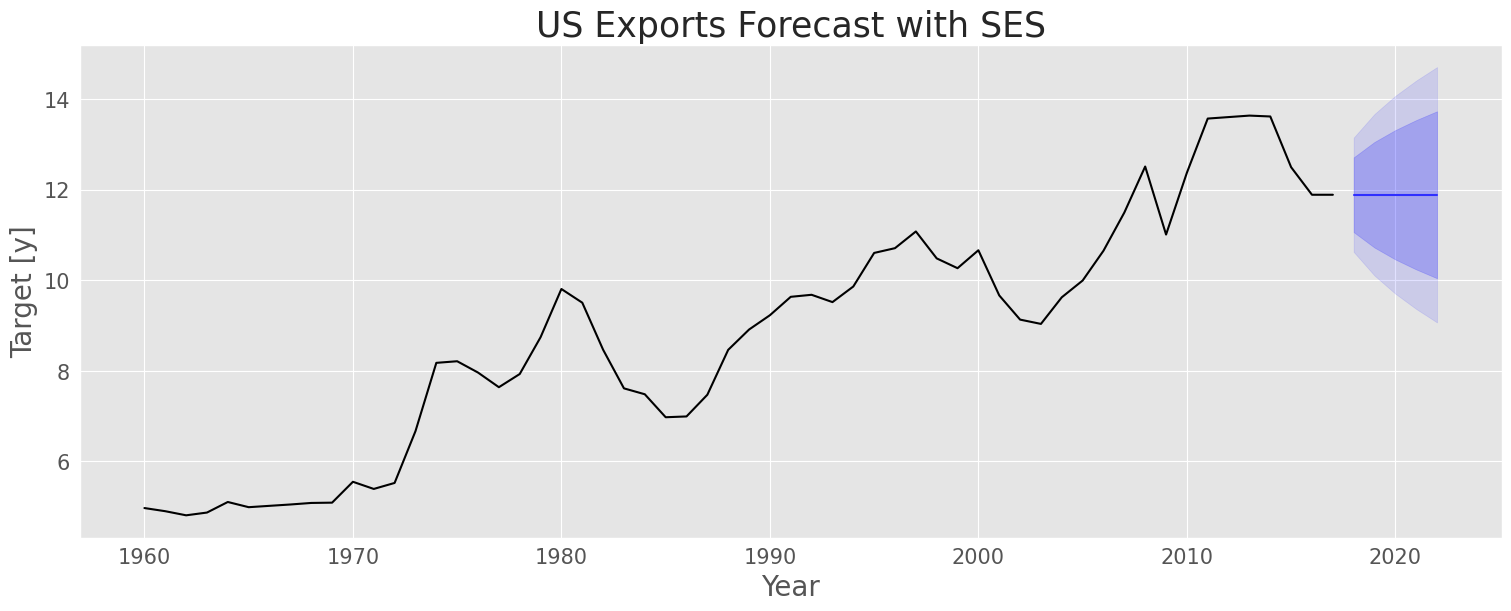

In [11]:
sf = StatsForecast(models=[AutoETS(model="ANN", alias="SES")], freq="Y")
fc = sf.forecast(df=df, h=5, level=[80, 95], fitted = True)
fig1 = plot_series(df, fc, level = [80, 95], xlabel="Year", title="US Exports Forecast with SES")


display(fig1)

In [12]:
fitted_vals = sf.forecast_fitted_values()
evaluation_results = evaluate(
    df=fitted_vals, 
    metrics=[rmse], 
    models=["SES"] 
)

# 4. View the results
display(evaluation_results)

,unique_id,metric,SES
0,United States,rmse,0.621


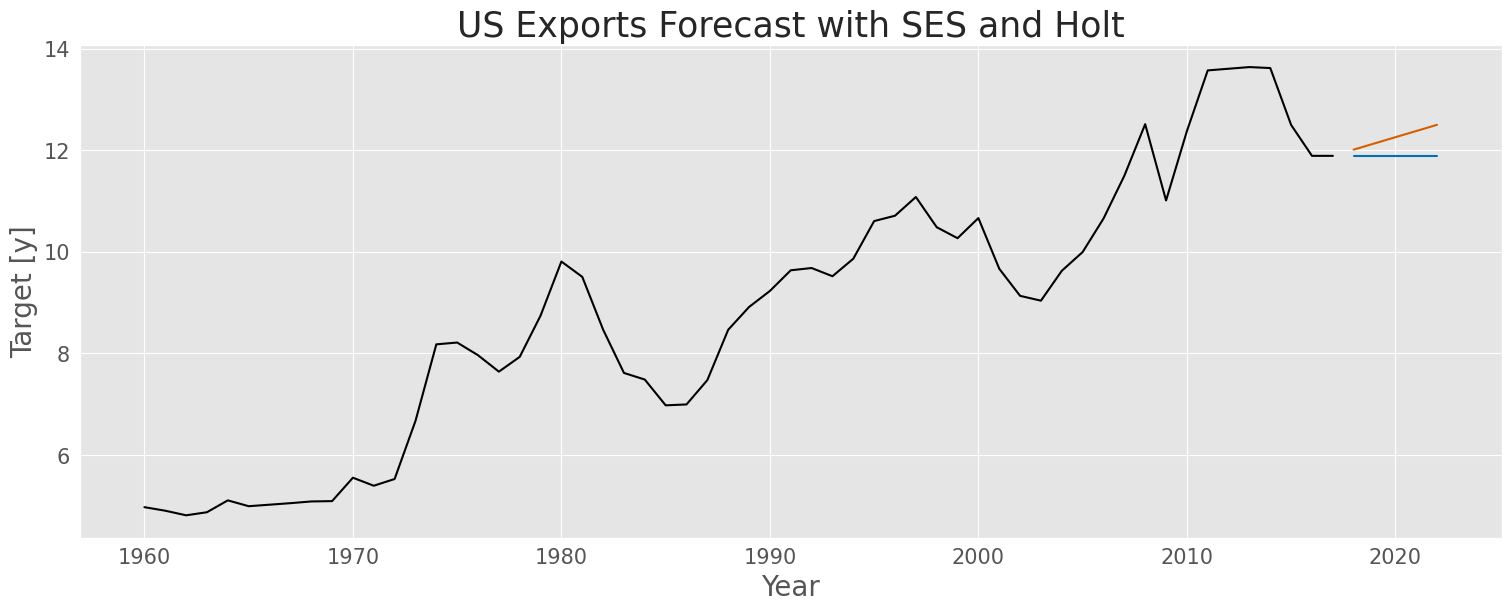

,unique_id,metric,SES,Holt
0,United States,rmse,0.621,0.609


In [13]:
sf = StatsForecast(models=[
    AutoETS(model="ANN", alias="SES"),
    AutoETS(model="AAN", alias="Holt")], freq="Y")
forecasts = sf.forecast(df=df, h=5, level=[95], fitted=True)
fig2 = plot_series(df, forecasts, xlabel="Year", title="US Exports Forecast with SES and Holt", 
                   palette="black_and_2color", )
display(fig2)
fitted_vals_1 = sf.forecast_fitted_values()
evaluation_results = evaluate(
    df=fitted_vals_1, 
    metrics=[rmse], 
    models=["SES", "Holt"] 
)

# 4. View the results
display(evaluation_results)

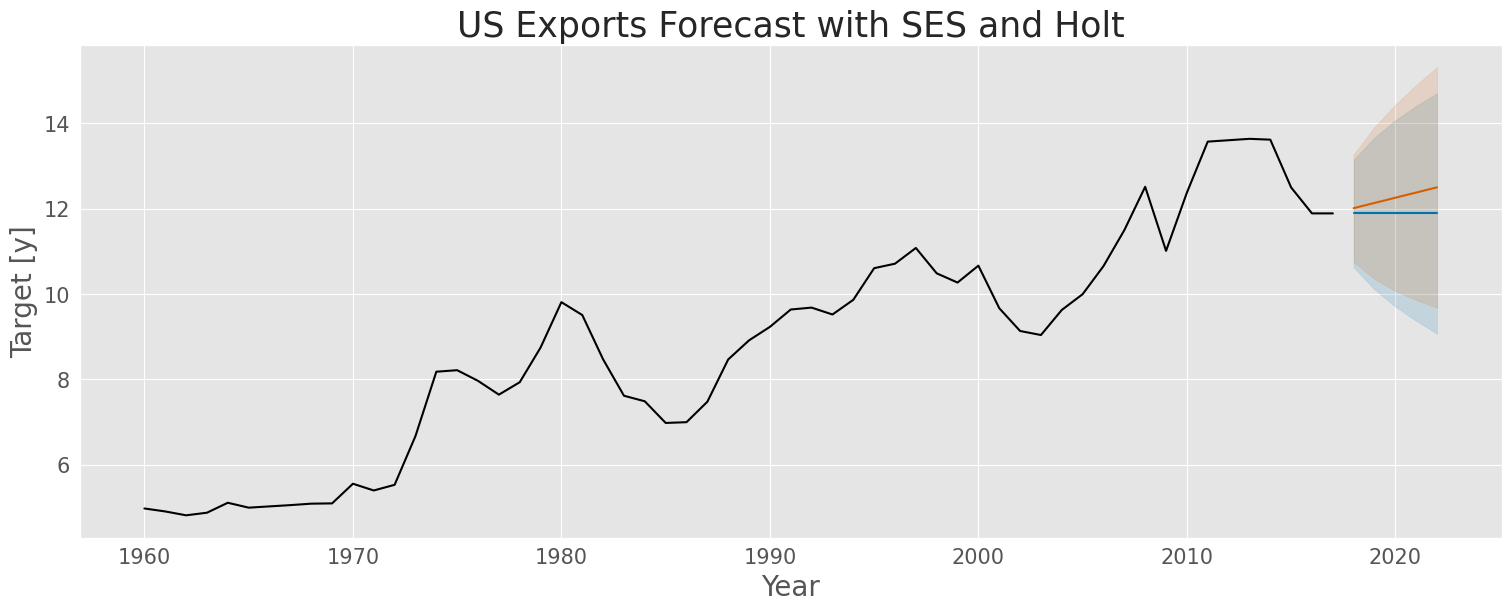

In [14]:
fig3 = plot_series(df, forecasts, level=[95], xlabel="Year", title="US Exports Forecast with SES and Holt", 
                   palette="black_and_2color", )
display(fig3)

In [15]:
# Assuming 'rmse_val' is the float value of your calculated RMSE
z_score = 1.96
rmse_val_SES= 0.621
rmse_val_Holt= 0.609
# Calculate manual intervals for the first forecast step
fc_step_1 = forecasts.groupby('unique_id').head(1).copy()

fc_step_1['Manual_SES_LO_95'] = fc_step_1['SES'] - (z_score * rmse_val_SES)
fc_step_1['Manual_SES_HI_95'] = fc_step_1['SES'] + (z_score * rmse_val_SES)
fc_step_1['Manual_Holt_LO_95'] = fc_step_1['Holt'] - (z_score * rmse_val_Holt)
fc_step_1['Manual_Holt_HI_95'] = fc_step_1['Holt'] + (z_score * rmse_val_Holt)
print(fc_step_1[['unique_id', 'ds', 'SES', 'Manual_SES_LO_95', 'Manual_SES_HI_95', 'Holt', 'Manual_Holt_LO_95', 'Manual_Holt_HI_95']])

       unique_id         ds     SES  Manual_SES_LO_95  Manual_SES_HI_95  \
0  United States 2017-12-31  11.891            10.673            13.108   

     Holt  Manual_Holt_LO_95  Manual_Holt_HI_95  
0  12.013             10.819             13.206  


In [16]:
forecasts.head(1)

,unique_id,ds,SES,SES-lo-95,SES-hi-95,Holt,Holt-lo-95,Holt-hi-95
0,United States,2017-12-31,11.891,10.629,13.152,12.013,10.752,13.274


### 6. Forecast the Chinese GDP from the `chinese_gdp` data set using an ETS model. Note that the values for the GDP have already been transformed with a division by $10^6$ for ease of use. Experiment with the various `AutoETS()` options to see how much the forecasts change with damped trend, or with a Box-Cox transformation. Try to develop an intuition of what each is doing to the forecasts.

[Hint: use a relatively large value of h when forecasting, so you can clearly see the differences between the various options when plotting the forecasts.]

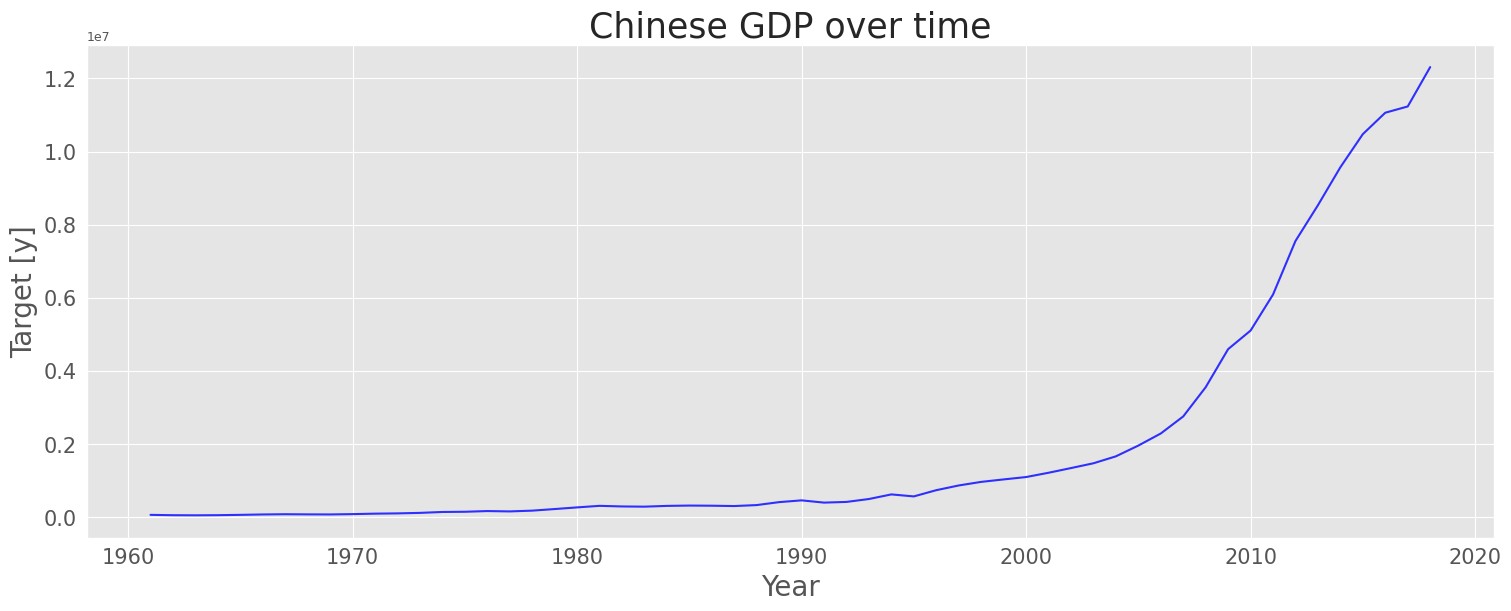

In [17]:
chn = (
    pd.read_csv(DATA_DIR / "chinese_gdp.csv", parse_dates=["Date"])
    .rename(columns={"Date": "ds", "GDP": "y", "Country": "unique_id"})
    .reset_index(drop=True)
    )

fig = plot_series(chn, xlabel="Year", title="Chinese GDP over time")
display(fig)

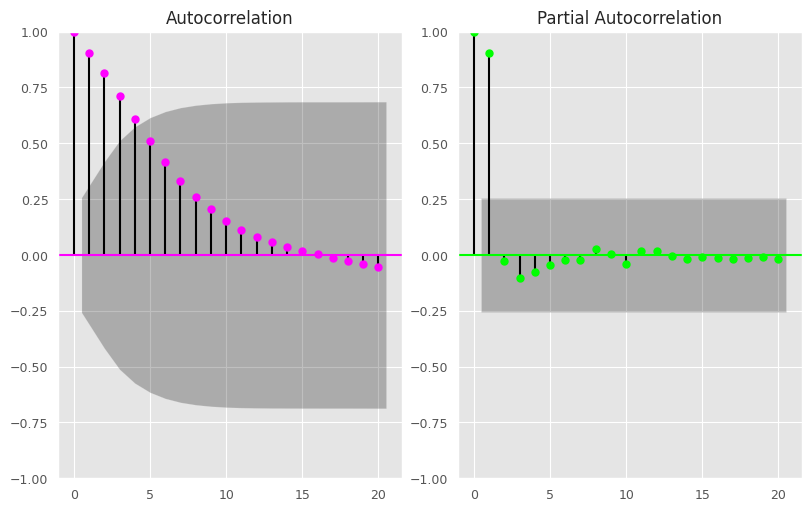

In [18]:
fig, axs = plt.subplots(nrows=1, ncols=2)

plot_acf(chn["y"],  lags=20, ax=axs[0],color="fuchsia")
axs[0].set_title("Autocorrelation");

# Plot
plot_pacf(chn["y"],  lags=20, ax=axs[1],color="lime")
axs[1].set_title('Partial Autocorrelation')

plt.show();

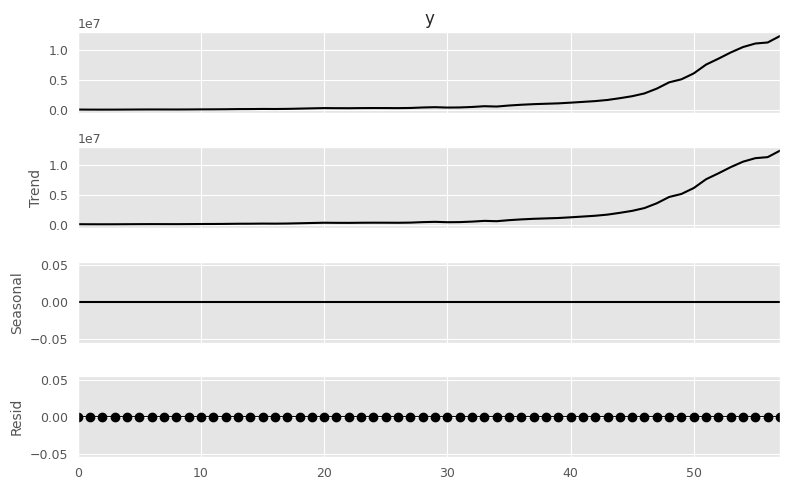

In [19]:
from statsmodels.tsa.seasonal import seasonal_decompose
a = seasonal_decompose(chn["y"], model = "add", period=1)
a.plot();

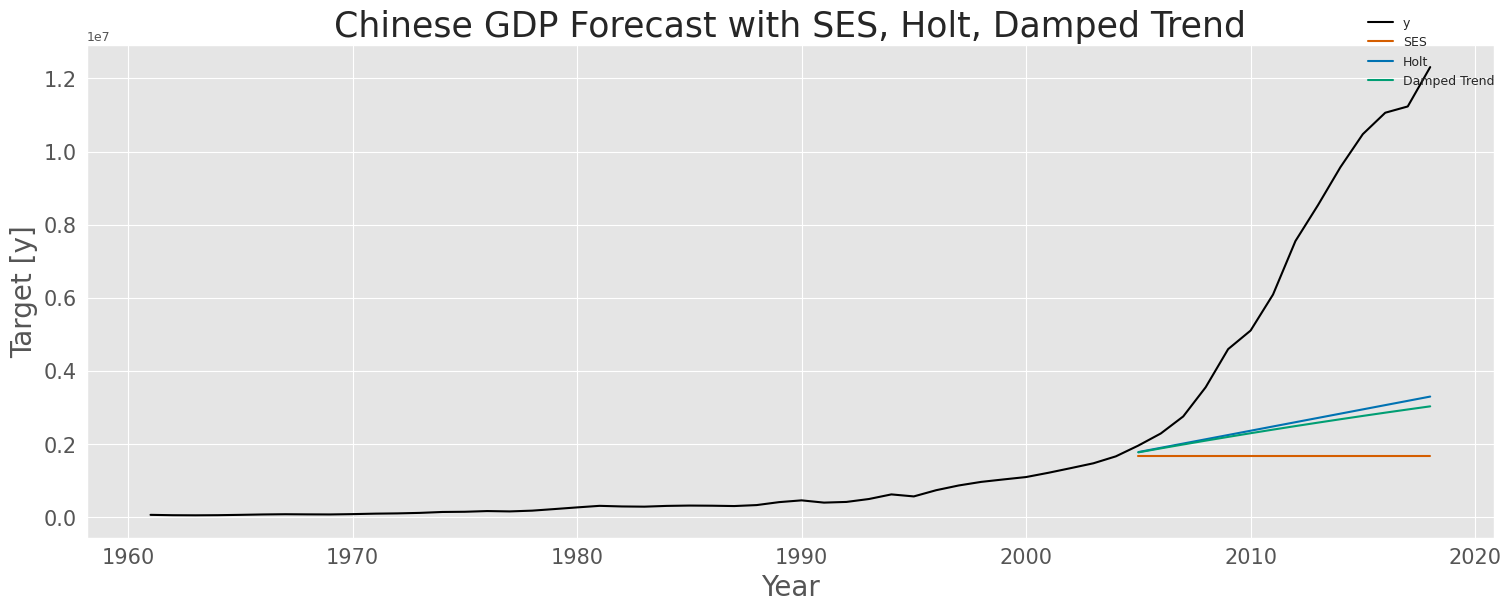

In [20]:
train = chn[chn["ds"] <= "2003-12-31"]
test = chn[chn["ds"] > "2003-12-31"]

# Because the series is non-seasonal, we choose the non-seasonal models: SES and Holt (AAN)
models = AutoETS(model="ANN", alias="SES"), AutoETS(model="AAN", alias="Holt"), AutoETS(season_length=1, model='ZAZ', damped=True, alias="Damped Trend")
sf = StatsForecast(models=models, freq="YE")
forecasts = sf.forecast(df = train, h=len(test), fitted = True).assign(y= test['y'].to_numpy())
fig4 = plot_series(train, forecasts, xlabel="Year", title="Chinese GDP Forecast with SES, Holt, Damped Trend", 
                   palette="black_and_3color", rm_legend=False,)
display(fig4)

In [21]:
fitted_vals = sf.forecast_fitted_values()
eval_results = evaluate(
    df=fitted_vals, 
    metrics=[rmse, mae],
    models=["SES", "Holt", "Damped Trend"]
)
display(eval_results)

,unique_id,metric,SES,Holt,Damped Trend
0,China,rmse,66647.306,44649.276,45688.903
1,China,mae,44563.443,29881.398,30491.052


In [22]:
def plot_diagnostics(data):
    fig, axes = plt.subplot_mosaic([["resid", "resid"], ["acf", "hist"]])

    ax = axes["resid"]
    ax.plot(data["ds"], data["resid"])
    ax.set(title="Innovation Residuals")

    ax = axes["acf"]
    plot_acf(
        data["resid"].dropna(),
        zero=False,
        bartlett_confint=False,
        auto_ylims=True,
        ax=ax,
    )
    ax.set(title="ACF Plot", xlabel="lag[1]", ylabel="acf")

    ax = axes["hist"]
    ax.hist(data["resid"].dropna(), bins=20)
    ax.set(title="Histogram", xlabel="resid", ylabel="count")

    return fig

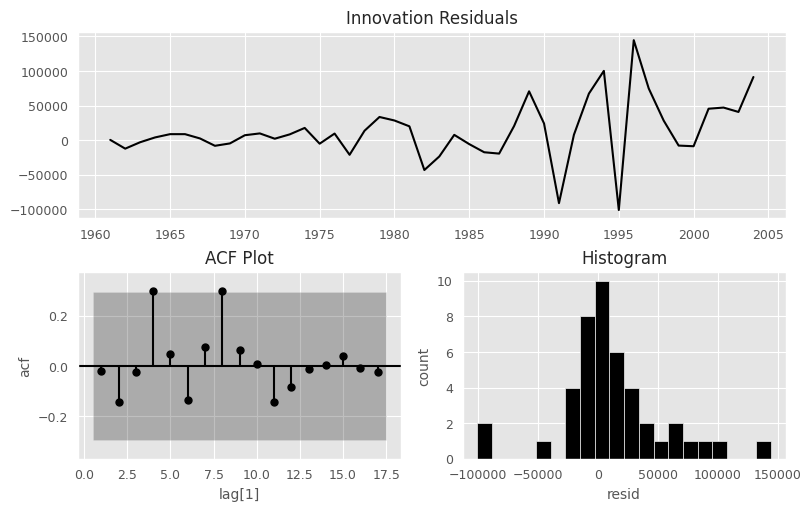

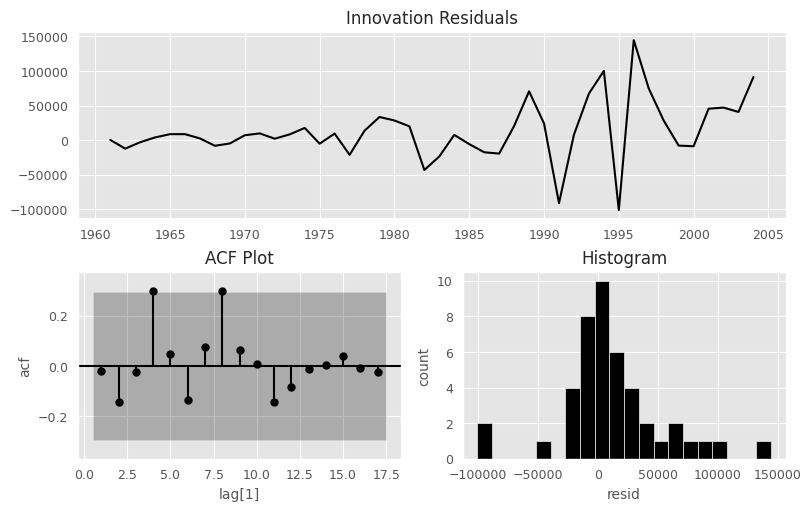

In [23]:
sf.forecast(h=len(test), df=train, fitted=True)

p = sf.forecast_fitted_values().assign(
    resid=lambda x: x["y"] - x["Holt"]
)

fig2 = plot_diagnostics(p)
display(fig2)

### 7. Find an ETS model for the Gas data from `aus_production` and forecast the next few years. Why is multiplicative seasonality necessary here? Experiment with making the trend damped. Does it improve the forecasts?

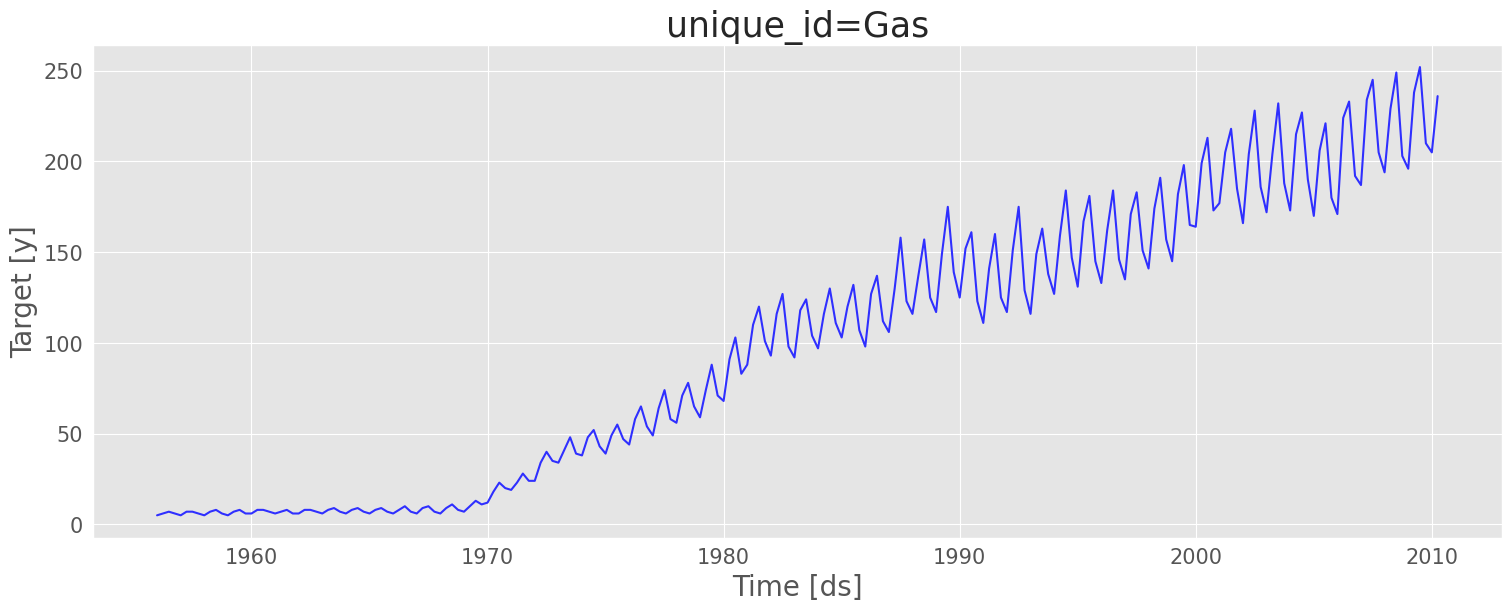

In [24]:
aus_production = (
    pd.read_csv(DATA_DIR / "aus_production.csv", parse_dates=["ds"])
    .assign(unique_id="Gas")
    .rename(columns={"ds": "ds", "Gas": "y"})
    [[ "y", "ds", "unique_id" ]]
)


fig  = plot_series(aus_production)
display(fig)

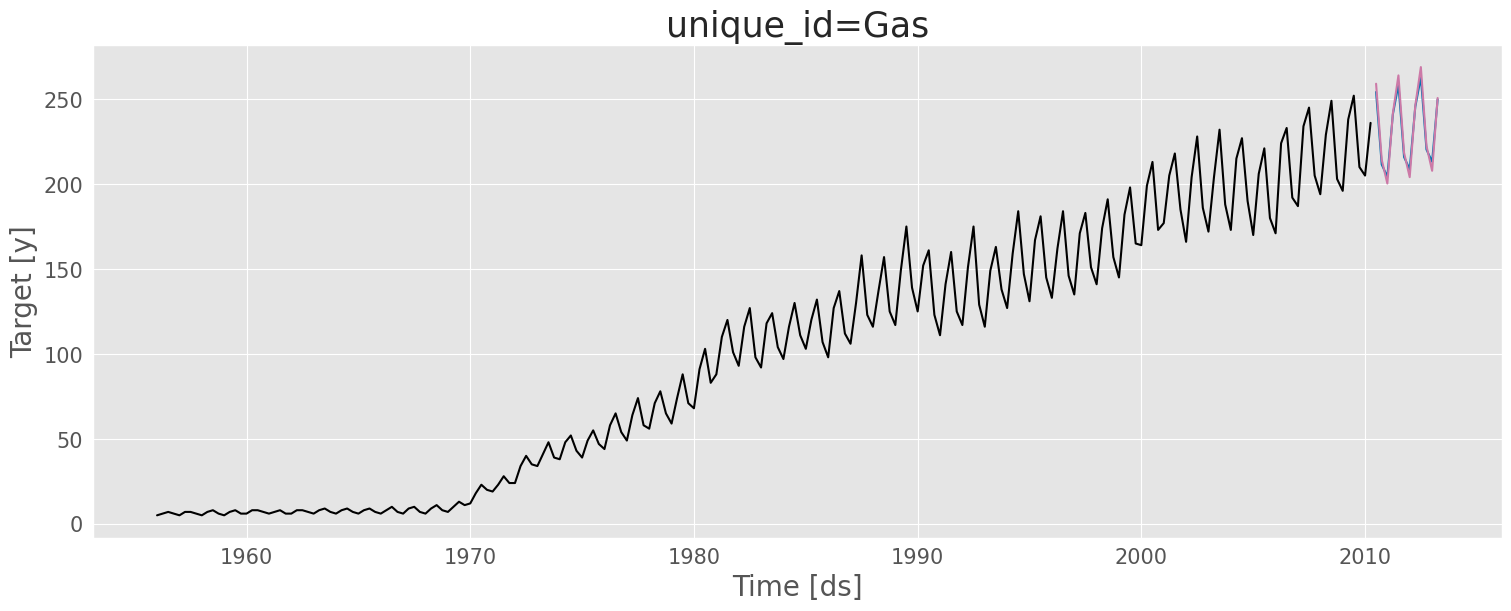

In [25]:
# Because the series is high seasonal, we choose the seasonal models: SES, AAA, MAM, Damped Seasonal.
models =[HoltWinters(season_length=4, error_type="A", alias="additive"),
    HoltWinters(season_length=4, error_type="M", alias="multiplicative")]
# models = [
#     AutoETS(model="ANN", alias="SES"),
#     AutoETS(model="AAA", season_length=4, alias="AAA"),
#     AutoETS(model="MAM", season_length=4, alias="MAM"),
#     AutoETS(model="AAA", season_length=4, damped=True, alias="Damped Seasonal"),
# ]
sf = StatsForecast(
    models=models,
    freq="Q",   # quarterly year-end dates; use "Q" if QE gives trouble
)
forecasts = sf.forecast(df=aus_production, h=12, fitted=True)
fig5 = plot_series(
    aus_production,
    forecasts,
    palette="black_and_4color",
)
display(fig5)

In [26]:
fitted_vals = sf.forecast_fitted_values()
eval_results = evaluate(
    df=fitted_vals, 
    metrics=[rmse, mae],
    # models=["SES", "AAA", "MAM", "Damped Seasonal"]
    models=["additive", "multiplicative"]
)
display(eval_results)

,unique_id,metric,additive,multiplicative
0,Gas,rmse,4.406,4.571
1,Gas,mae,2.965,3.047


### 8. Recall your retail time series data (from Exercise 7 in Section 2.10).

a. Why is multiplicative seasonality necessary for this series?

b. Apply Holt-Winters’ multiplicative method to the data. Experiment with making the trend damped.

c. Compare the RMSE of the one-step forecasts from the two methods. Which do you prefer?

d. Check that the residuals from the best method look like white noise.

e. Now find the test set RMSE, while training the model to the end of 2010. Can you beat the Seasonal Naïve approach from Exercise 7 in Section 5.11?

> Note:
* Additive Seasonality (Constant Amplitude)
    * You use an additive method when the magnitude of the seasonal fluctuations remains relatively constant over time, regardless of whether the overall series is trending up or down.
    * In an additive model, the seasonal component is expressed in absolute units (e.g., "sales increase by 500 units in December"). If your business grows over five years, that December spike remains roughly exactly +500 units above the trend line.
    * Math Concept: $y_t = \text{Level} + \text{Trend} + \text{Seasonality}$

    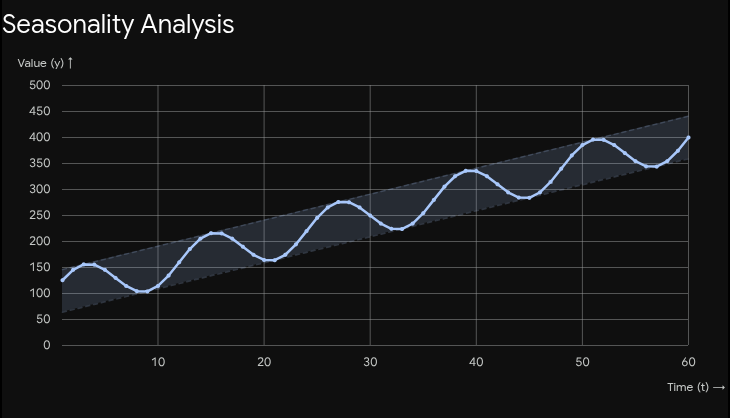

* Multiplicative Seasonality (Proportional Amplitude)   
    * You use a multiplicative method when the seasonal variations change in proportion to the overall level of the series.
    * In a multiplicative model, the seasonal component is expressed as a percentage or ratio (e.g., "sales increase by 20% in December"). If your business is small, a 20% spike might mean +50 units. If your business grows exponentially, that same 20% seasonal spike might mean +5,000 units. The "shape" of the seasonality looks like a megaphone, getting wider as the trend goes up. 
    * Math Concept: $y_t = (\text{Level} + \text{Trend}) \times \text{Seasonality}$

    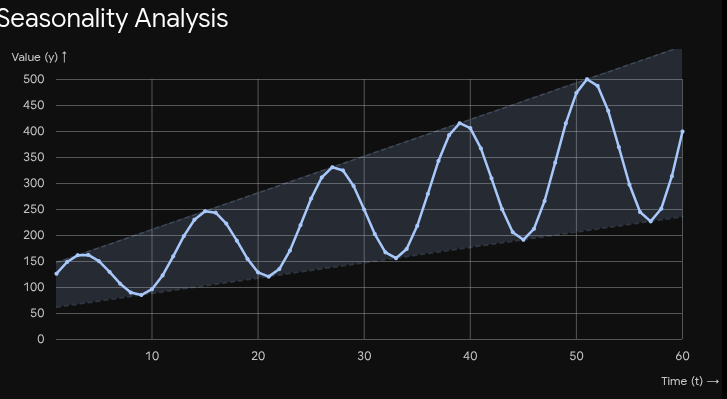


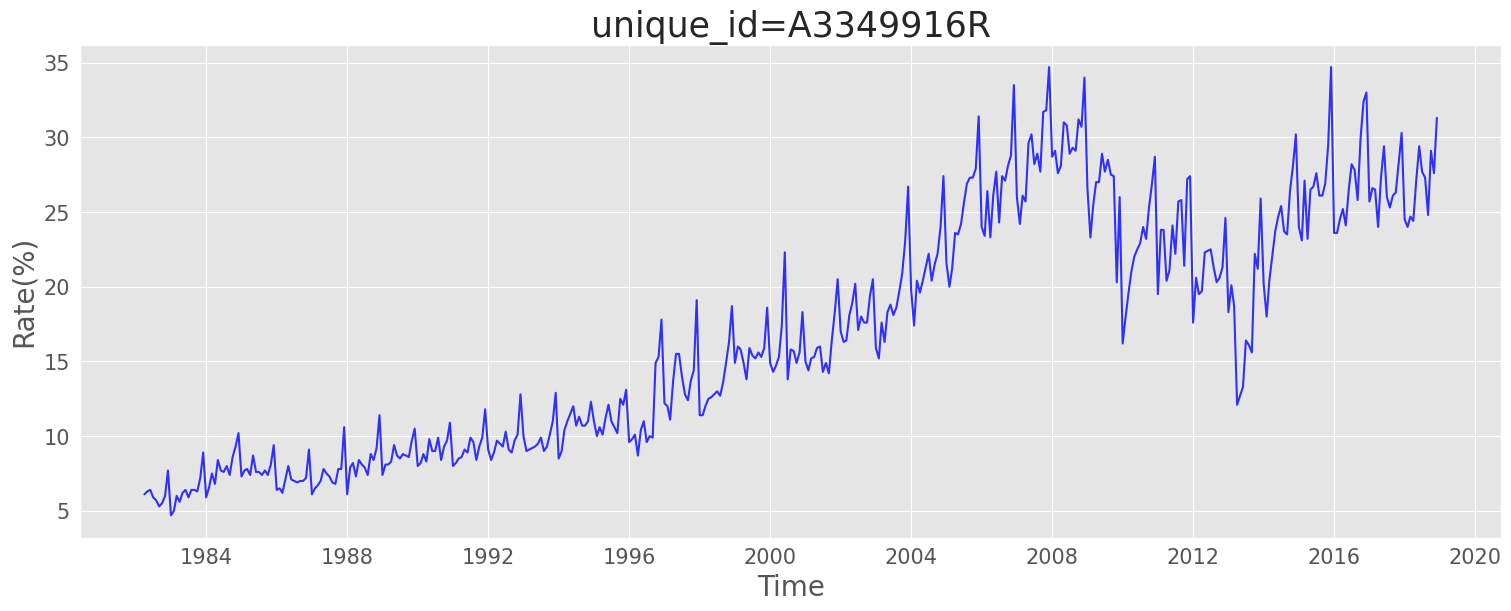

In [51]:
# a.
aus_retail = pd.read_csv(DATA_DIR / "aus_retail.csv", parse_dates = ['Month'])
aus_retail

random = np.random.RandomState(42)
random_series_id = random.choice(aus_retail["Series ID"].unique())
myseries = aus_retail.loc[aus_retail["Series ID"] == random_series_id]
myseries = myseries[["Series ID", "Month", "Turnover"]].rename(columns={"Turnover": "y", "Month": "ds", "Series ID": "unique_id"}).reset_index(drop=True)

# Time Series Plot
fig1 = plot_series(myseries, time_col = 'ds', id_col = 'unique_id', target_col = 'y')
for ax in fig1.axes:
    ax.set_ylabel("Rate(%)")
    ax.set_xlabel("Time")
display(fig1)

# It's necessary because the series has a strong seasonal pattern and seasonal variations changes in proportion. 
# So, The multiplicative model can capture this type of seasonality better than the additive model, which assumes constant seasonal variations.

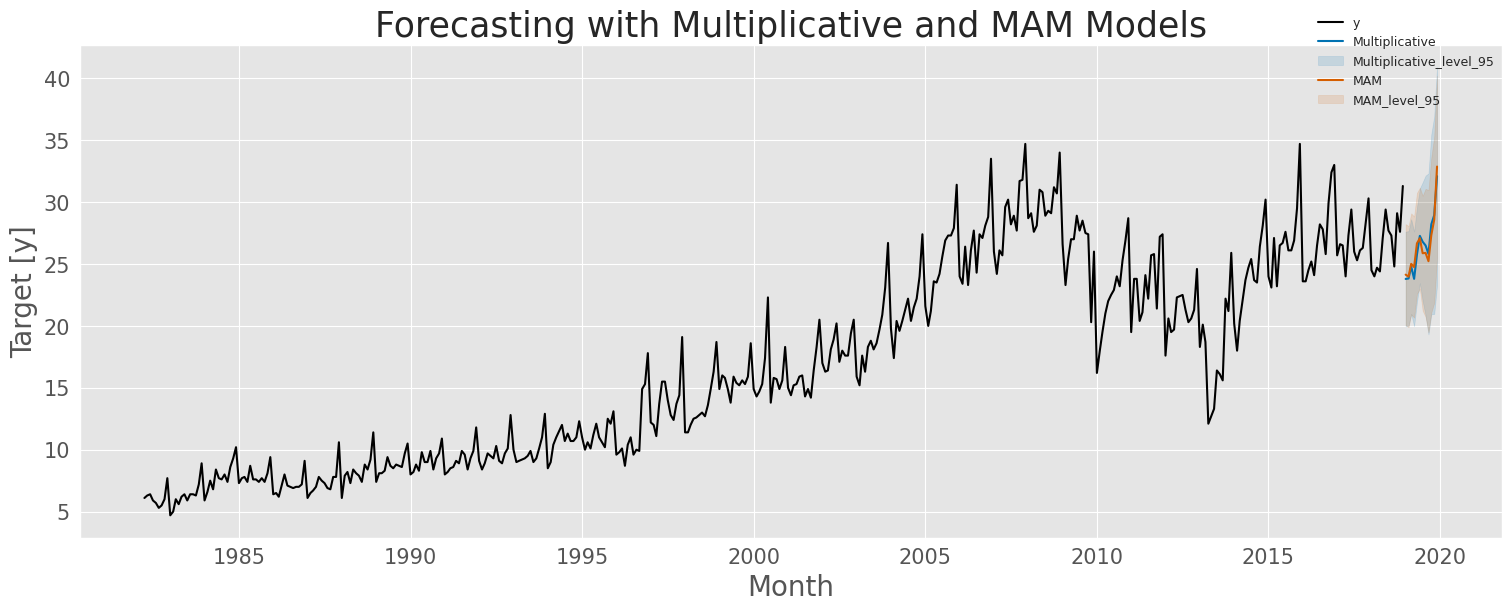

,unique_id,metric,Multiplicative,MAM
0,A3349916R,rmse,1.442,1.525
1,A3349916R,mae,0.946,1.002


In [52]:
models = [HoltWinters(season_length=12, error_type="M", alias="Multiplicative"),
          AutoETS(model="MAM", damped=True, season_length=12, alias="MAM")]
sf = StatsForecast(models=models, freq="M")
forecasts = sf.forecast(df=myseries, h=12, level=[95], fitted=True)
fig2 = plot_series(myseries, forecasts, level=[95], xlabel="Month", title="Forecasting with Multiplicative and MAM Models", palette="black_and_2color", rm_legend=False)
display(fig2)

fitted_vals = sf.forecast_fitted_values()
eval_results = evaluate(
    df=fitted_vals, 
    metrics=[rmse, mae],
    models=["Multiplicative", "MAM"]
)
display(eval_results)

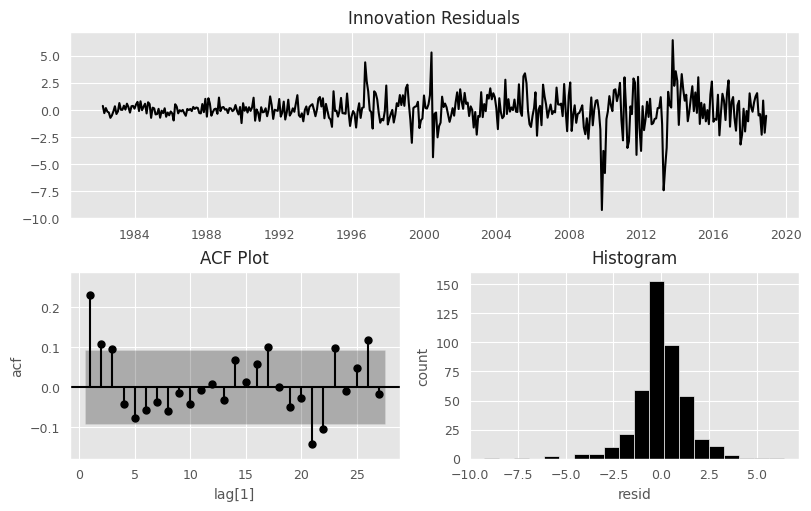

In [53]:
sf.forecast(h=12, df=myseries, fitted=True)

p = sf.forecast_fitted_values().assign(
    resid=lambda x: x["y"] - x["Multiplicative"]
)

fig3 = plot_diagnostics(p)

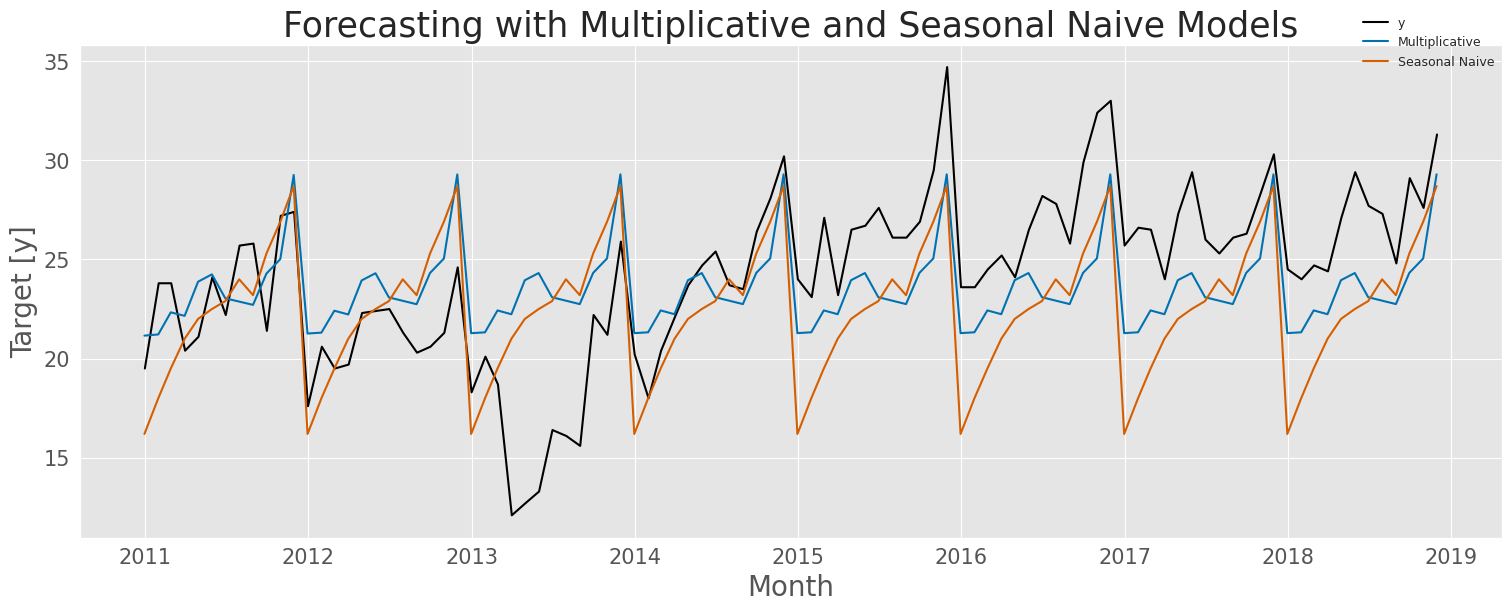

,unique_id,metric,Multiplicative,Seasonal Naive
0,A3349916R,rmse,1.338,2.312
1,A3349916R,mae,0.845,1.599


In [70]:
train = myseries.loc[:344, :]
test = myseries.loc[345:, :]

models = [HoltWinters(season_length=12, error_type="M", alias="Multiplicative"),
          SeasonalNaive(season_length=12, alias="Seasonal Naive")]
sf = StatsForecast(models=models, freq="M")
forecasts = sf.forecast(df=train, h=len(test), level=[95], fitted=True)

fig4 = plot_series(test, forecasts, xlabel="Month", title="Forecasting with Multiplicative and Seasonal Naive Models", palette="black_and_2color", rm_legend=False)
display(fig4)

fitted_vals = sf.forecast_fitted_values()
evaluation_results = evaluate(
    df=fitted_vals, 
    metrics=[rmse, mae],
    models=["Multiplicative", "Seasonal Naive"]
)
display(evaluation_results)

So, we can see that HoltWinter model with multiplicative method has a lower accuracy than Seasonal Naive Method. 

### 9. For the same retail data, try an STL decomposition applied to the Box-Cox transformed series, followed by ETS on the seasonally adjusted data. How does that compare with your best previous forecasts on the test set?


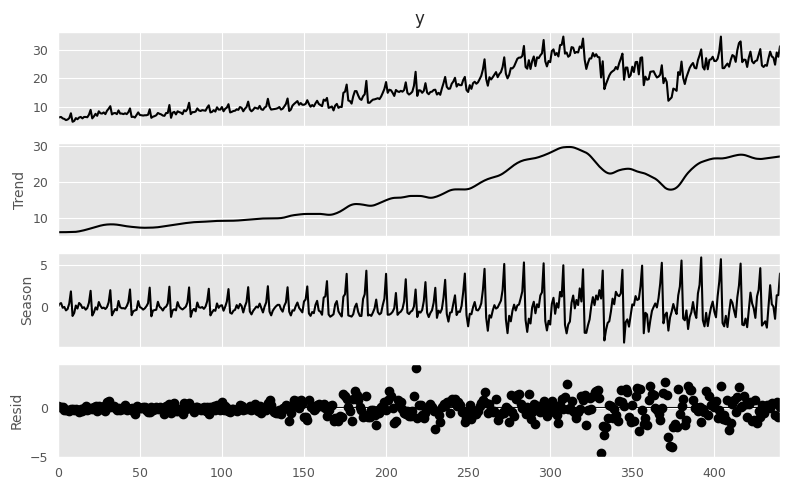

In [99]:
stl = STL(train["y"], period=12)
res = stl.fit()
fig5 = res.plot()

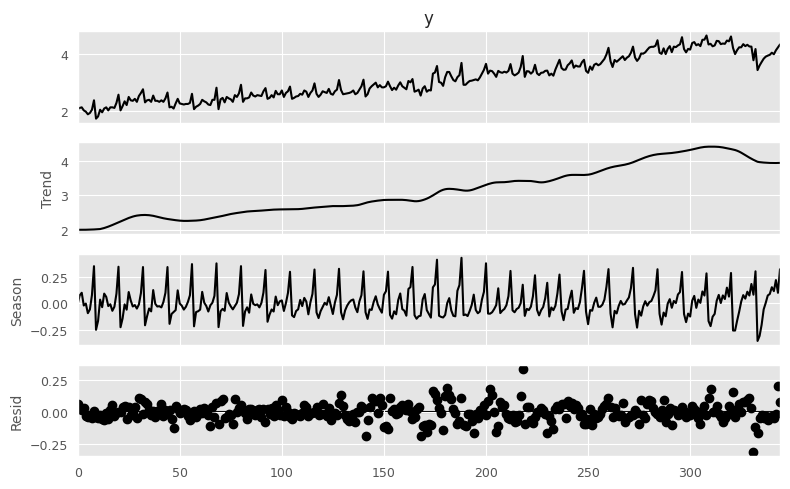

In [101]:
y = train['y'].to_numpy()
optim_lambda = boxcox_lambda(y , method = 'guerrero', season_length = 12)
train_boxcox = train.assign(y = boxcox(y, optim_lambda))
test_boxcox = test.assign(y = boxcox(test['y'], optim_lambda))

stl_1 = STL(train_boxcox["y"], period=12)
res_1 = stl_1.fit()
fig6 = res_1.plot()

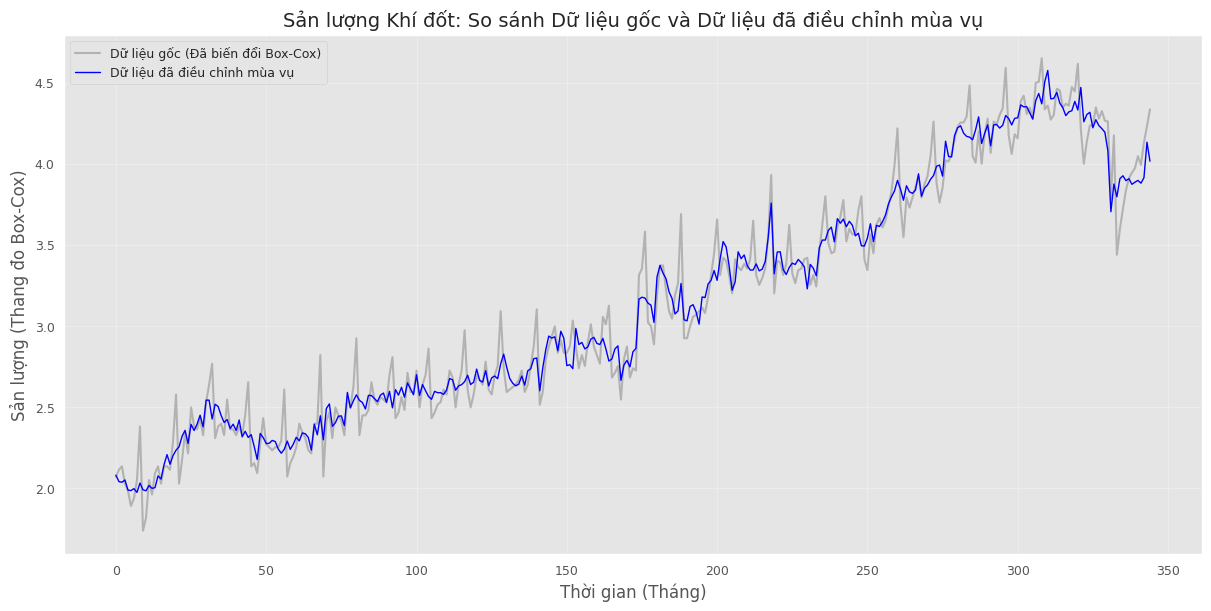

In [102]:
seasonally_adjusted_gas = train_boxcox['y'] - res_1.seasonal
train_boxcox['Adjusted'] = seasonally_adjusted_gas.to_frame(name='y')    


plt.figure(figsize=(12, 6))
plt.plot(train_boxcox['y'], label='Dữ liệu gốc (Đã biến đổi Box-Cox)', color='gray', alpha=0.5)
plt.plot(train_boxcox['Adjusted'], label='Dữ liệu đã điều chỉnh mùa vụ', color='blue', linewidth=1)

plt.title('Sản lượng Khí đốt: So sánh Dữ liệu gốc và Dữ liệu đã điều chỉnh mùa vụ', fontsize=14)
plt.xlabel('Thời gian (Tháng)', fontsize=12)
plt.ylabel('Sản lượng (Thang đo Box-Cox)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

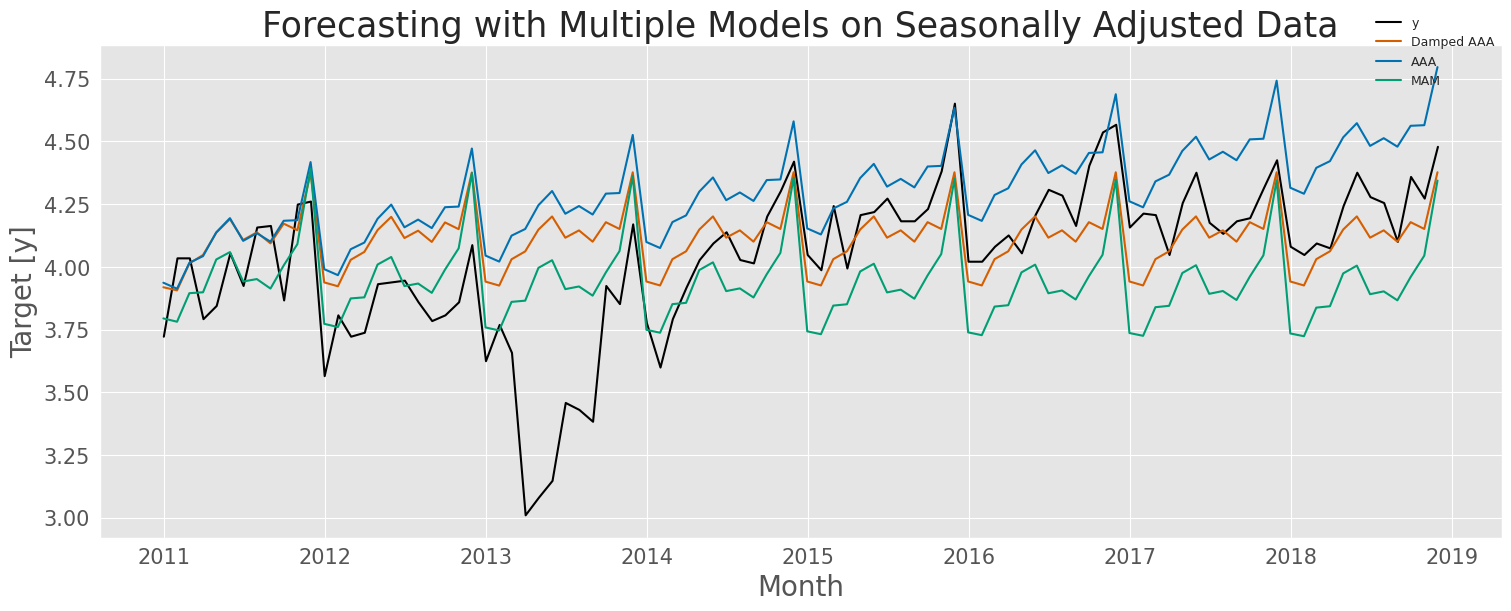

,unique_id,metric,Damped AAA,AAA,MAM
0,A3349916R,rmse,0.113,0.109,0.131
1,A3349916R,mae,0.083,0.078,0.095


In [108]:
models = [AutoETS(model="AAA", season_length=12, damped = True ,alias="Damped AAA"),
          AutoETS(model="AAA", season_length=12, alias="AAA"),
          AutoETS(model="MAM", season_length=12, alias="MAM")]
sf = StatsForecast(models=models, freq="M")
forecasts = sf.forecast(df=train_boxcox, h=len(test_boxcox), level=[95], fitted=True)
fig7 = plot_series(test_boxcox, forecasts, xlabel="Month", title="Forecasting with Multiple Models on Seasonally Adjusted Data", palette="black_and_3color", rm_legend=False)
display(fig7)

fitted_vals = sf.forecast_fitted_values()
evaluation_results = evaluate(
    df=fitted_vals,
    metrics=[rmse, mae],
    models=["Damped AAA", "AAA", "MAM"]
)
display(evaluation_results)

> How does that compare with your best previous forecasts on the test set?

we can see that the models are better forecasts than the previous models as we applied Box-Cox transformation and then used seasonally adjusted data. 

This proven that we should seperate the forecast between trend-cycle and seasonality. Ultimately, we add them into the final.

### 10. Compute the total domestic overnight trips across Australia from the `tourism` dataset.

a. Plot the data and describe the main features of the series.

b. Decompose the series using MSTL and obtain the seasonally adjusted data.

c. Forecast the next two years of the series using an additive damped trend method applied to the seasonally adjusted data. (This can be specified using damped=True.)

d. Forecast the next two years of the series using an appropriate model for Holt’s linear method applied to the seasonally adjusted data (as before but without `damped trend`).

e. Now use `AutoETS()`to choose a seasonal model for the data.

f. Compare the RMSE of the ETS model with the RMSE of the models you obtained using MSTL decomposition. Which gives the better in-sample fits?

g. Compare the forecasts from the three approaches. Which seems most reasonable?

h. Check the residuals of your preferred model

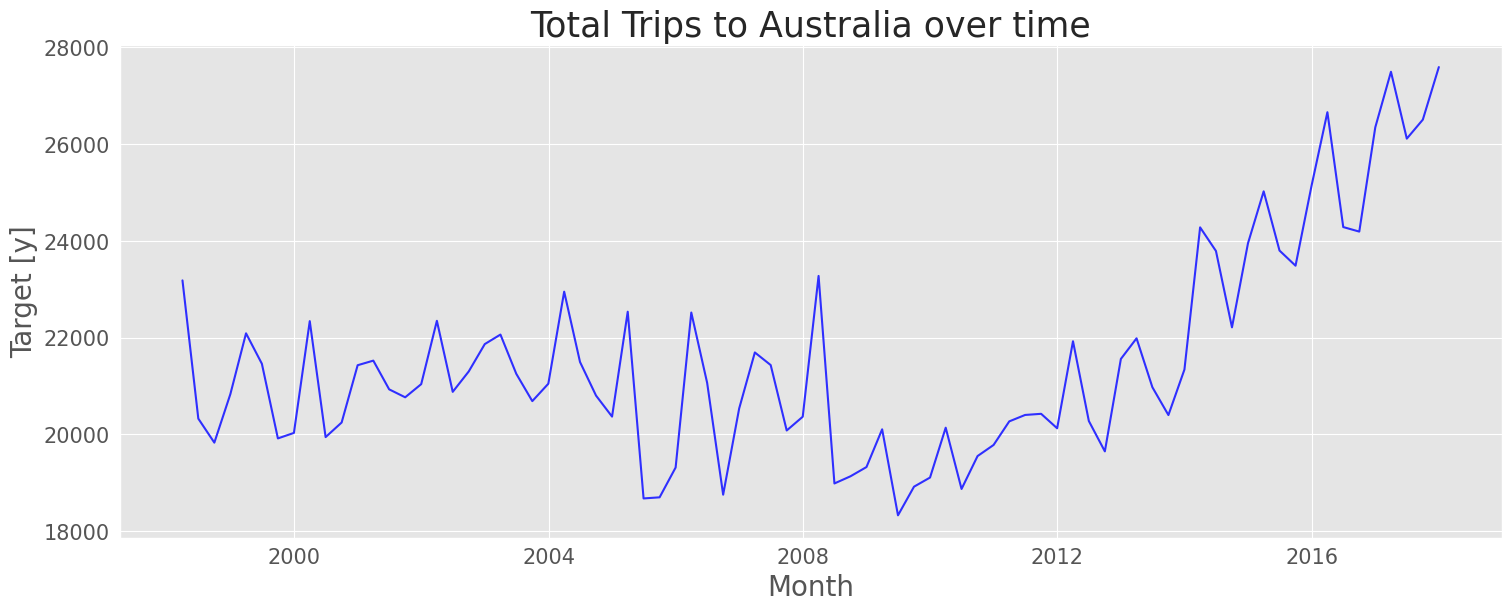

,unique_id,min,p25,median,p75,max
0,Australia,18323.825,20118.254,21040.919,22388.918,27593.554


In [125]:
tourism = pd.read_csv(DATA_DIR / "aus_tourism.csv", parse_dates=["ds"])

aus_trips = (
    tourism.groupby("ds", as_index=False)["y"]
    .sum()
    .assign(unique_id="Australia")
    [["unique_id", "ds", "y"]]
)

fig = plot_series(aus_trips, xlabel="Month", title="Total Trips to Australia over time")
display(fig)

summary_stats = tsf.tsfeatures(aus_trips, freq = 12, features = [tsf.statistics], scale = False)
summary_stats[["unique_id", "min", "p25", "median", "p75", "max"]]

### 11. For this exercise use the quarterly number of arrivals to Australia from New Zealand, 1981 Q1 – 2012 Q3, from data set `aus_arrivals`.

a. Make a time plot of your data and describe the main features of the series.

b. Create a training set that withholds the last two years of available data. Forecast the test set using an appropriate model for Holt-Winters’ multiplicative method.

c. Why is multiplicative seasonality necessary here?

d. Forecast the two-year test set using each of the following methods:
    * an ETS model;
    * an additive ETS model applied to a log transformed series;
    * a Seasonal Naïve method;
    * a MSTL decomposition applied to the log transformed data followed by an ETS model applied to the seasonally adjusted (transformed) data.

e. Which method gives the best forecasts? Does it pass the residual tests?

f. Compare the same four methods using time series cross-validation instead of using a training and test set. Do you come to the same conclusions?

### 12. 
a. Apply cross-validation techniques to produce 1 year ahead ETS and Seasonal Naïve forecasts for Portland cement production (from `aus_production`). Use a stretching data window with initial size of 5 years, and increment the window by one observation.
> Note: A stretching window (also known as an expanding window) is a dynamic cross-validation or training approach where your training set starts at a fixed beginning point and continually grows by adding one observation (or time period) at a time.
* For quarterly data:
    * 5 years = 5 * 4 = 20 observations
    * increment by one observation = move forward one quarter each time
    * each window uses all data from the start up to that point
* Other common windowing techniques:
    * Stretching (Expanding) Window: Starts at \(t=1\) and grows \([1, 2], [1, 2, 3], [1, 2, 3, 4]\).
    * Rolling (Sliding) Window: Maintains a fixed size and moves forward \([1, 2, 3], [2, 3, 4], [3, 4, 5]\).
    * Fixed Origin: Starts at a fixed point and evaluates successive fixed-length periods \([1, 2], [1, 2, 3], [1, 2, 3, 4]\).
    
b. Compute the MSE of the resulting 4-step-ahead errors. Comment on which forecasts are more accurate. Is this what you expected?

In [146]:
cement = (
    pd.read_csv(DATA_DIR / "aus_production.csv", parse_dates=["ds"])
    .assign(unique_id="Cement")
    .rename(columns={"Cement": "y"})
    [["unique_id", "ds", "y"]]
)

initial = 5 * 4   # 5 years of quarterly data
h = 4             # 1 year ahead

sf = StatsForecast(
    models=[
        AutoETS(season_length=4, alias="ETS"),
        SeasonalNaive(season_length=4, alias="SeasonalNaive"),
    ],
    freq="QS",
)

cv_df = sf.cross_validation(
    df=cement,
    h=h,
    step_size=1,
    n_windows=len(cement) - initial - h + 1,
)

cv_df["horizon"] = cv_df.groupby(["unique_id", "cutoff"]).cumcount() + 1

h4_errors = cv_df.query("horizon == 4").copy()

mse_4_step = pd.DataFrame({
    "model": ["ETS", "SeasonalNaive"],
    "MSE": [
        ((h4_errors["y"] - h4_errors["ETS"]) ** 2).mean(),
        ((h4_errors["y"] - h4_errors["SeasonalNaive"]) ** 2).mean(),
    ],
}).sort_values("MSE")

display(mse_4_step)

,model,MSE
0,ETS,18991.150
1,SeasonalNaive,19512.041


### 13. Compare `AutoETS()` and `SeasonalNaive()` from `StatsForecast` on the following five time series. Use a test set of three years to decide what gives the best forecasts.

* Beer and bricks production from `aus_production`.
* Cost of drug subsidies for diabetes (`ATC2 == "A10"`) and corticosteroids (`ATC2 == "H02"`) from `pbs`.
* Total food retailing turnover for Australia from `aus_retail`.

In [181]:
gas = (
    pd.read_csv(DATA_DIR / "aus_production.csv", parse_dates=["ds"])
    .assign(unique_id="Gas")
    .rename(columns={"ds": "ds", "Gas": "y"})
    [["y", "ds", "unique_id"]]
) # quaterly

bricks = (
    pd.read_csv(DATA_DIR / "aus_production.csv", parse_dates=["ds"])
    .assign(unique_id="Bricks").interpolate(method='linear')
    .rename(columns={"ds": "ds", "Bricks": "y"})
    [["y", "ds", "unique_id"]]
) # quaterly

diabetes = (
    pd.read_csv(DATA_DIR / "pbs.csv", parse_dates=["Month"])
    .query("ATC2 == 'A10'")
    .assign(unique_id="Diabetes")
    .rename(columns={"Month": "ds", "Cost": "y"})
    [["y", "ds", "unique_id"]].reset_index(drop=True)
) # monthly

corticosteroids = (
    pd.read_csv(DATA_DIR / "pbs.csv", parse_dates=["Month"])
    .query("ATC2 == 'H02'")
    .assign(unique_id="Corticosteroids")
    .rename(columns={"Month": "ds", "Cost": "y"})
    [["y", "ds", "unique_id"]].reset_index(drop=True)
) 

# myseries # monthly

In [182]:
def compare_SES_and_SeasonalNaive(data, h, freq, season_length):
    models = [SeasonalNaive(season_length=season_length, alias="Seasonal Naive"),
            AutoETS(model="AAN", alias="Holt"),
            AutoETS(model="AAA", season_length=season_length, alias="AAA"),
            AutoETS(model="MAM", season_length=season_length, alias="MAM"),]

    length = len(data)    
    if freq == "M" or freq == "MS":
        train = data.loc[:length - 37, :]
        test = data.loc[length - 36:, :]
    elif freq == "Q":
        train = data.loc[:length - 13, :]
        test = data.loc[length - 12:, :]
    else:
        raise ValueError("Unsupported frequency. Use 'M' for monthly or 'Q' for quarterly.")

    sf = StatsForecast(models=models, freq=freq)
    forecasts = sf.forecast(df=train, h=h, level=[95], fitted=True)
    fig = plot_series(test, forecasts, xlabel="Month", title="Forecasting with Multiple Models", palette="black_and_4color", rm_legend=False)      
    display(fig)
    fitted_vals = sf.forecast_fitted_values()
    evaluation_results = evaluate(
        df=fitted_vals,
        metrics=[rmse, mae],
        models=["Seasonal Naive", "AAA", "MAM"]
    )
    display(evaluation_results)

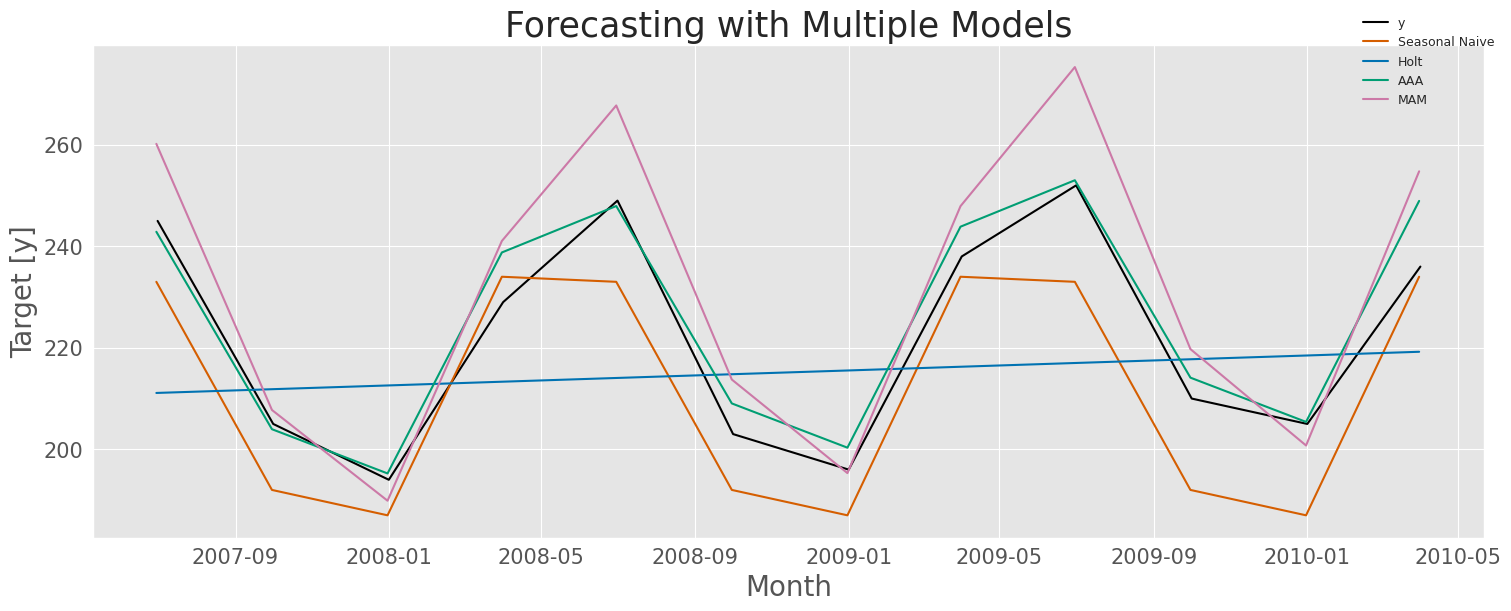

,unique_id,metric,Seasonal Naive,AAA,MAM
0,Gas,rmse,7.601,4.401,4.726
1,Gas,mae,5.535,2.937,3.033


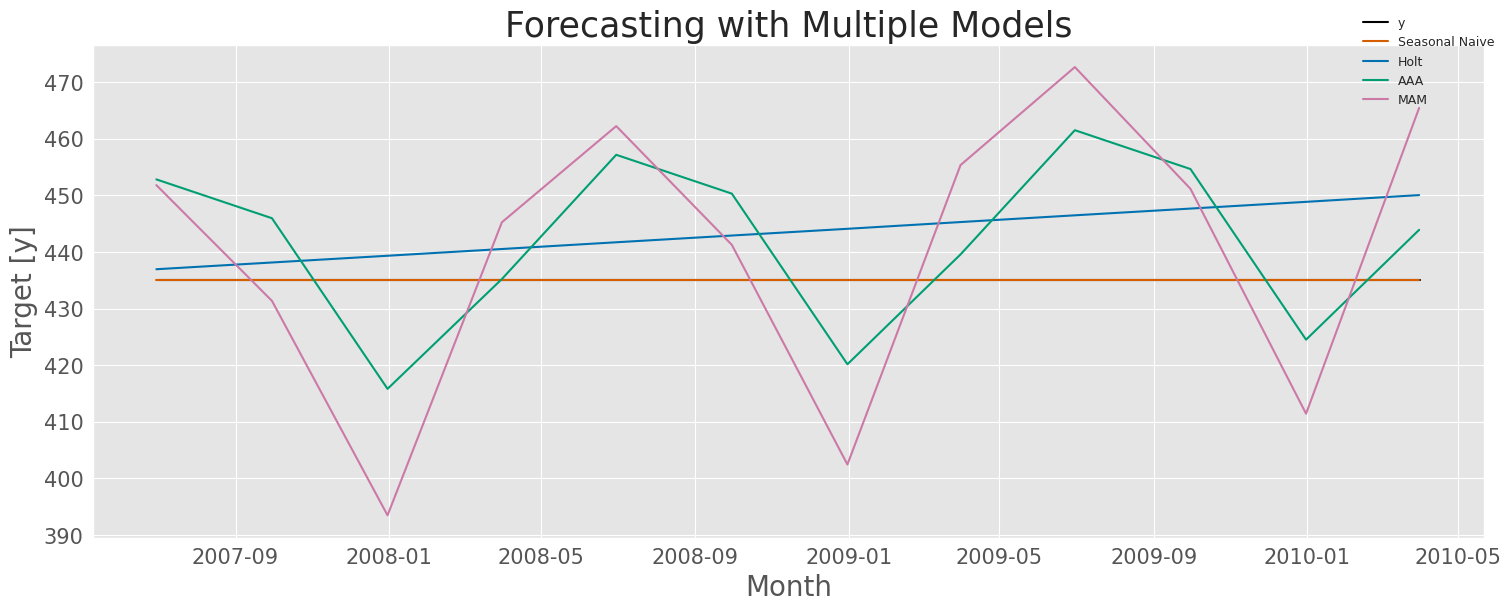

,unique_id,metric,Seasonal Naive,AAA,MAM
0,Bricks,rmse,47.775,21.924,22.302
1,Bricks,mae,34.693,15.917,16.172


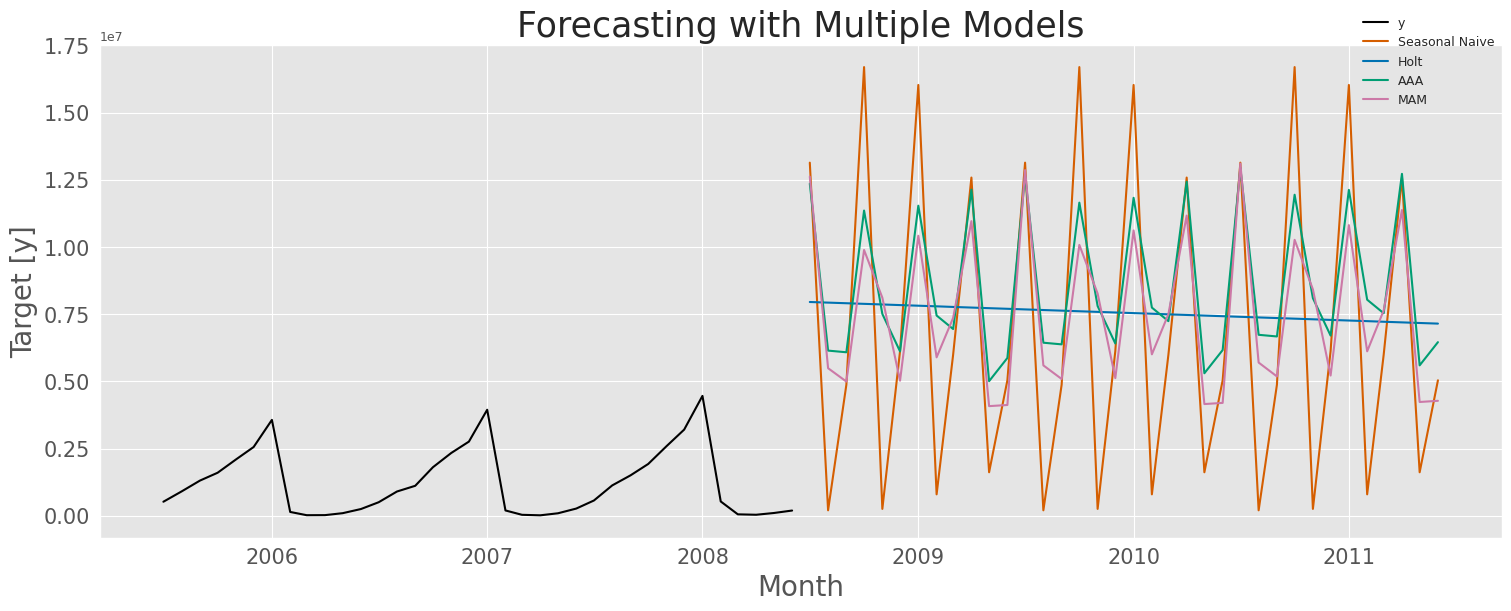

,unique_id,metric,Seasonal Naive,AAA,MAM
0,Diabetes,rmse,2.443e+06,1.840e+06,2.393e+06
1,Diabetes,mae,1.385e+06,1.096e+06,1.386e+06


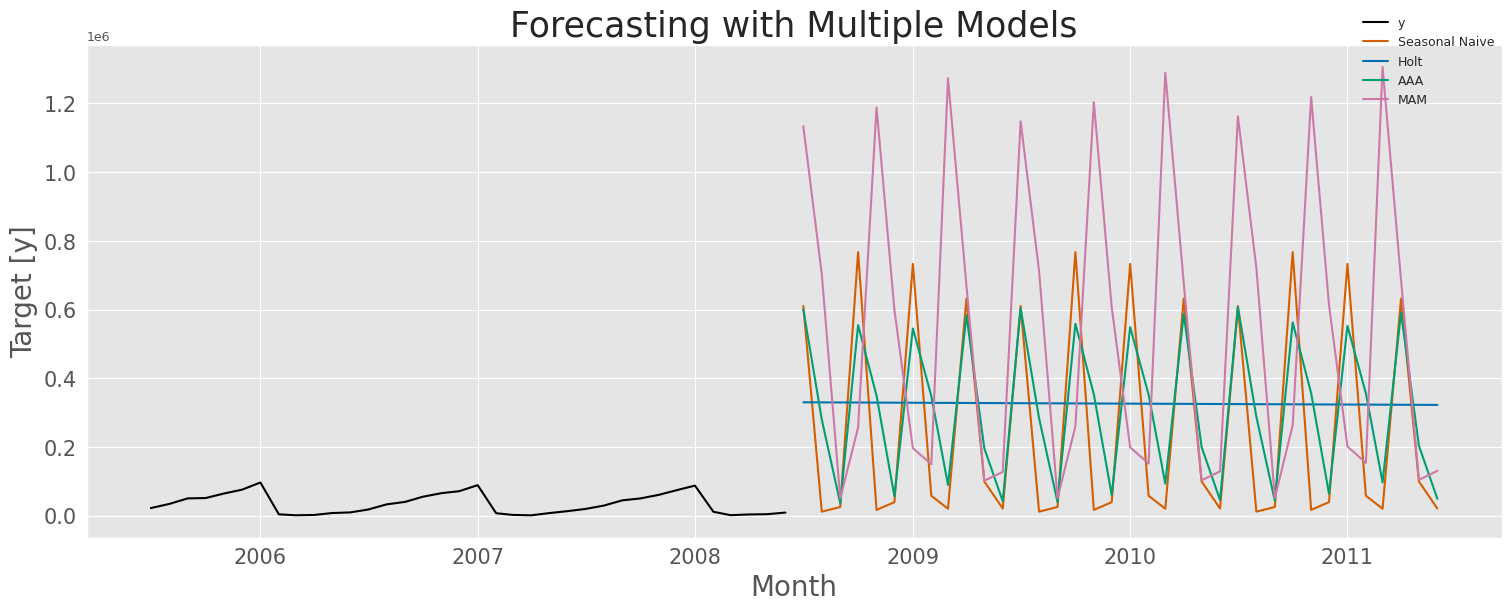

,unique_id,metric,Seasonal Naive,AAA,MAM
0,Corticosteroids,rmse,170792.511,134258.140,266310.225
1,Corticosteroids,mae,101352.452,85751.839,142870.187


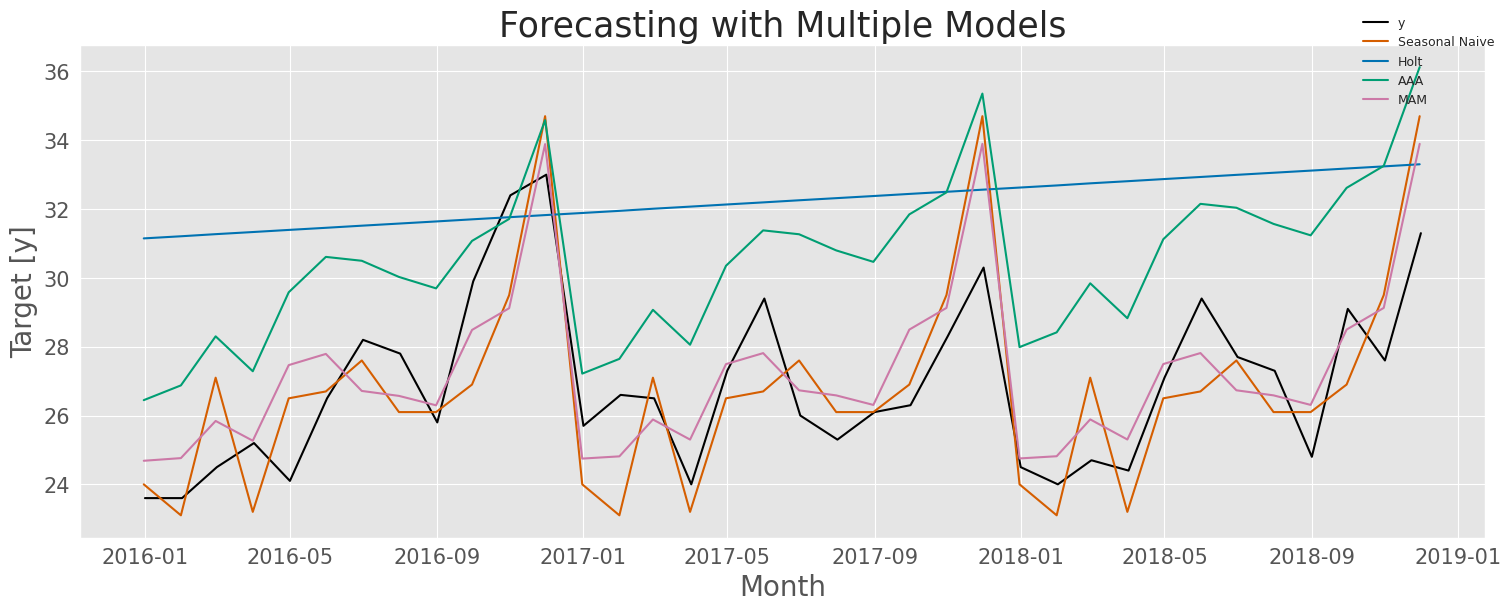

,unique_id,metric,Seasonal Naive,AAA,MAM
0,A3349916R,rmse,2.815,1.415,1.454
1,A3349916R,mae,1.915,0.934,0.944


In [183]:
compare_SES_and_SeasonalNaive(gas, h=12, freq="Q", season_length=4)
compare_SES_and_SeasonalNaive(bricks, h=12, freq="Q", season_length=4)
compare_SES_and_SeasonalNaive(diabetes, h=36, freq="MS", season_length=12)
compare_SES_and_SeasonalNaive(corticosteroids, h=36, freq="MS", season_length=12)
compare_SES_and_SeasonalNaive(myseries, h=36, freq="M", season_length=12)

### 14. 
a. Use `AutoETS()` to select an appropriate model for the following series: total number of trips across Australia using `tourism`, the closing prices for the four stocks in `gafa_stock`, and the lynx series in `pelt`. Does it always give good forecasts?

b. Find an example where it does not work well. Can you figure out why?

In [205]:
tourism = (pd.read_csv(DATA_DIR / "aus_tourism.csv", parse_dates=["ds"])
           .groupby("ds", as_index=False)["y"].sum()
           .assign(unique_id="Australia")
           [["unique_id", "ds", "y"]].reset_index(drop=True)
           )

stock = (
    pd.read_csv(DATA_DIR / "gafa_stock.csv", parse_dates=["ds"])
    .query("unique_id in ['AAPL_Close', 'AMZN_Close', 'FB_Close','GOOG_Close']")
    [["unique_id", "ds", "y"]].reset_index(drop=True)
)

lynx = (pd.read_csv(DATA_DIR / "pelt.csv", parse_dates=["ds"])
    .query("unique_id == 'lynx'")
    .reset_index(drop=True)
        )

In [215]:
def compare_AutoETS_model(data, h, freq, season_length):
    # Dynamically select models based on season length
    if season_length > 1:
        models = [
            AutoETS(model="ZZN", alias="Non-seasonal Naive"),
            AutoETS(model="AAA", season_length=season_length, alias="AAA"),
            AutoETS(model="MAM", season_length=season_length, alias="MAM"),
        ]
        model_aliases = ["Non-seasonal Naive", "AAA", "MAM"]
    else:
        # Only use non-seasonal models if season_length is 1
        models = [
            AutoETS(model="ZZN", alias="Non-seasonal Naive"),
            AutoETS(model="ZZZ", season_length=1, alias="Auto Non-seasonal")
        ]
        model_aliases = ["Non-seasonal Naive", "Auto Non-seasonal"]

    length = len(data)    
    if freq in ["M", "MS"]:
        train = data.loc[:length - 37, :]
        test = data.loc[length - 36:, :]
    elif freq == "Q":
        train = data.loc[:length - 13, :]
        test = data.loc[length - 12:, :]
    elif freq == "Y":
        train = data.loc[:length - 4, :]
        test = data.loc[length - 3:, :]
    else:
        raise ValueError("Unsupported frequency. Use 'M', 'Q', or 'Y'.")

    sf = StatsForecast(models=models, freq=freq)
    forecasts = sf.forecast(df=train, h=h, level=[95], fitted=True)
    
    # Update palette to match the dynamic number of models
    palette_name = f"black_and_{len(models)}color"
    fig = plot_series(test, forecasts, xlabel="Month", title="Forecasting with Multiple Models", palette=palette_name, rm_legend=False)      
    display(fig)
    
    fitted_vals = sf.forecast_fitted_values()
    evaluation_results = evaluate(
        df=fitted_vals,
        metrics=[rmse, mae],
        models=model_aliases
    )
    display(evaluation_results)


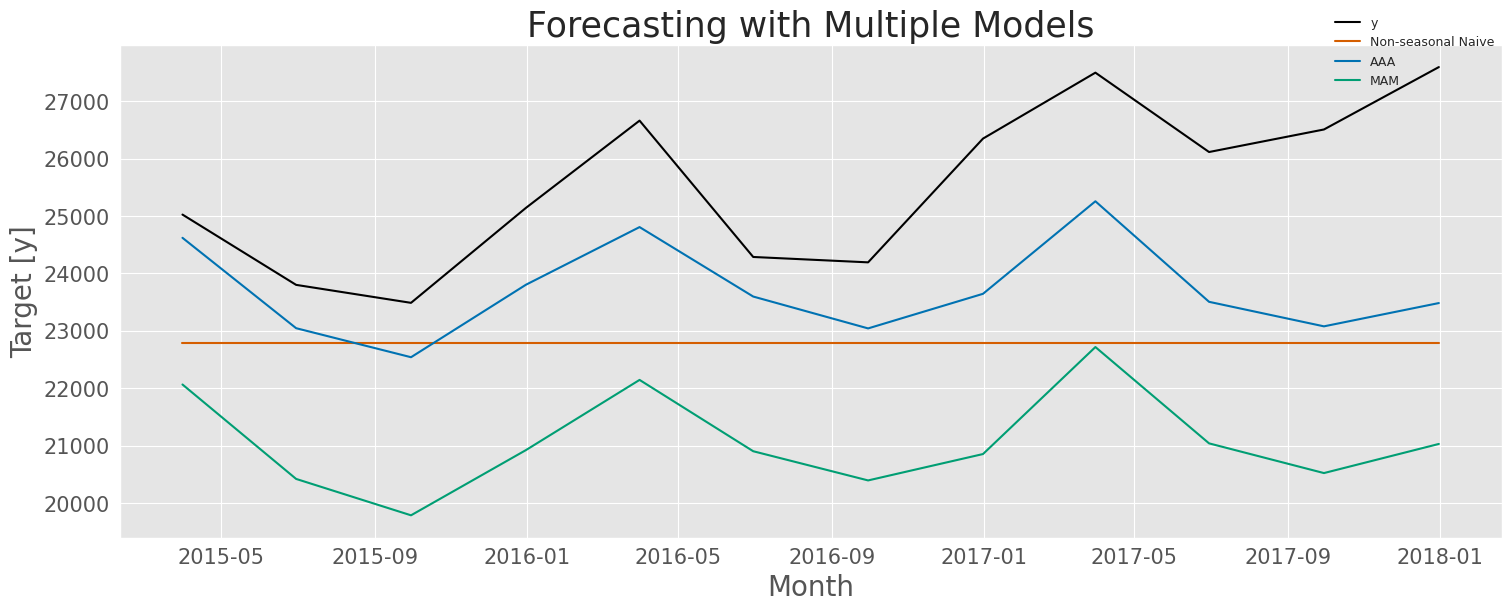

,unique_id,metric,Non-seasonal Naive,AAA,MAM
0,Australia,rmse,1233.472,835.983,1118.727
1,Australia,mae,976.157,642.854,855.494


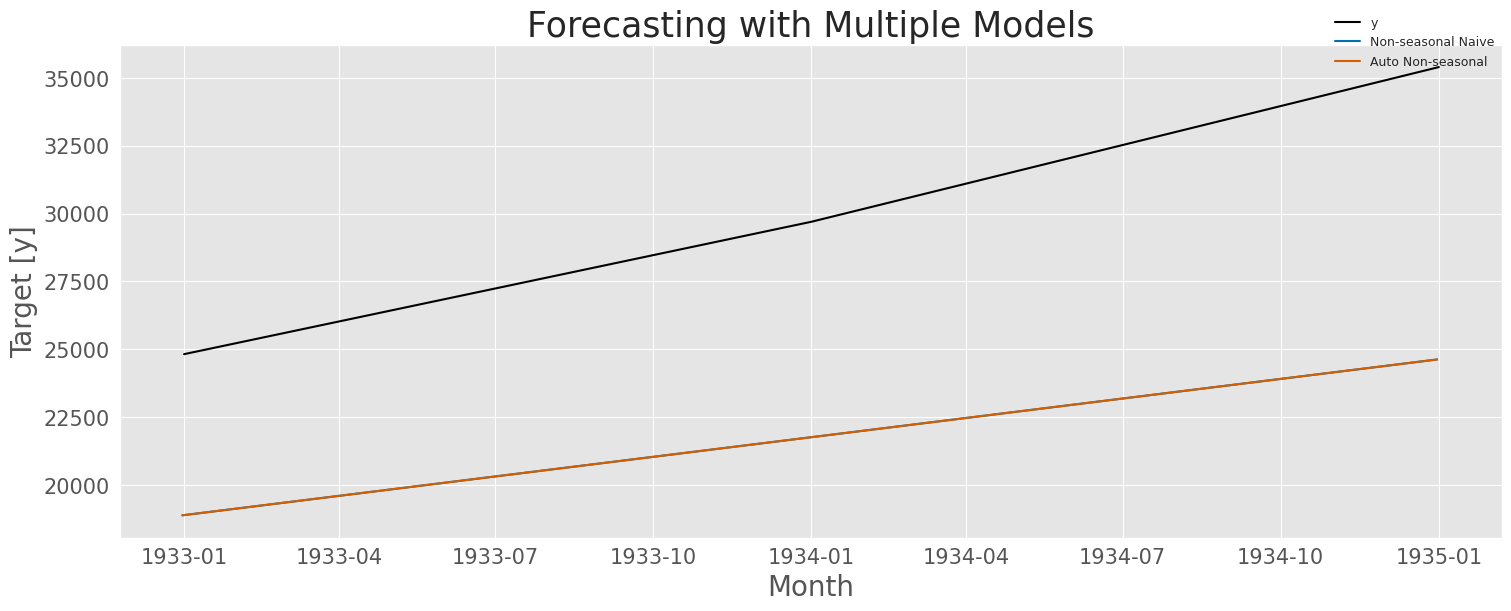

,unique_id,metric,Non-seasonal Naive,Auto Non-seasonal
0,lynx,rmse,13327.008,13327.008
1,lynx,mae,10088.737,10088.737


In [216]:
compare_AutoETS_model(tourism, h=12, freq="Q", season_length=12)
# compare_AutoETS_model(stock, h=36, freq="D", season_length=5)
compare_AutoETS_model(lynx, h=3, freq="Y", season_length=1)

### 15. Show that the point forecasts from an ETS(M,A,M) model are the same as those obtained using Holt-Winters’ multiplicative method.

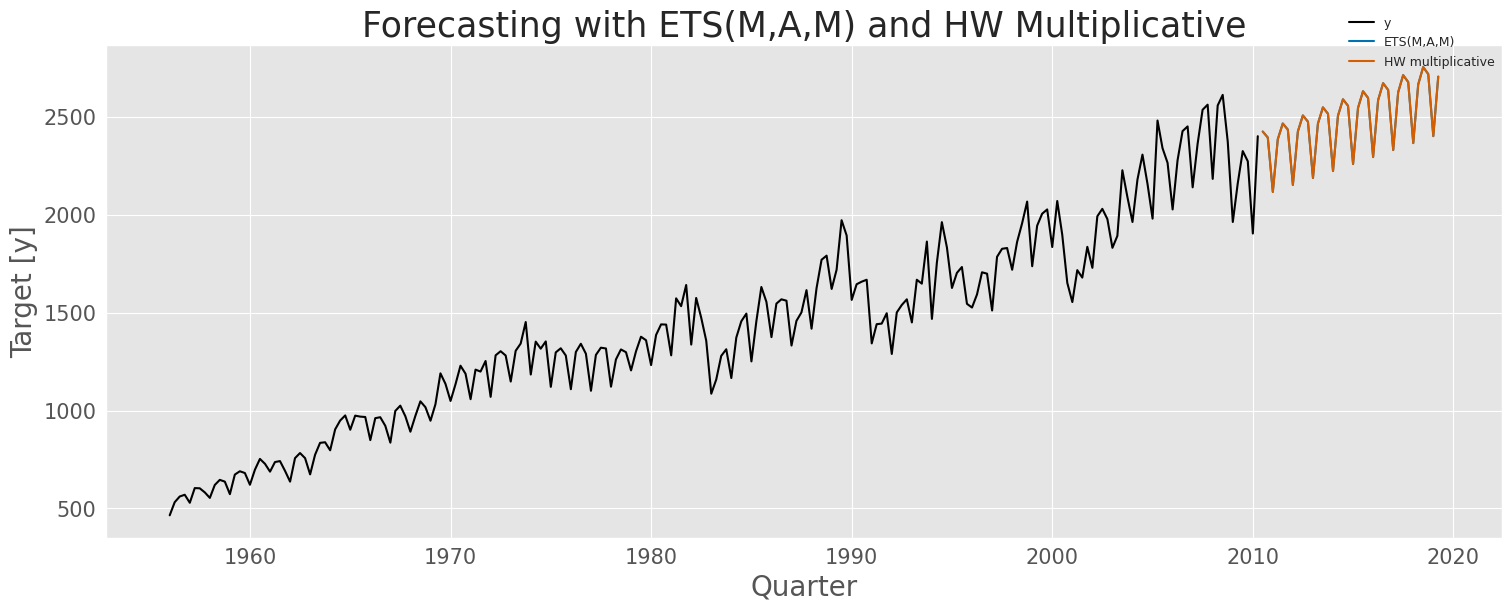

,unique_id,metric,"ETS(M,A,M)",HW multiplicative
0,Cement,rmse,76.562,76.562
1,Cement,mae,53.834,53.834


In [219]:
models = [AutoETS(model="MAM", season_length=4, alias="ETS(M,A,M)"),
           HoltWinters(season_length=4, error_type="M", alias="HW multiplicative")]
sf = StatsForecast(models=models, freq="Q")
forecasts = sf.forecast(df=cement, h=36, level=[95], fitted=True)
fig = plot_series(cement, forecasts, xlabel="Quarter", title="Forecasting with ETS(M,A,M) and HW Multiplicative", palette="black_and_2color", rm_legend=False)
display(fig)
fitted_vals = sf.forecast_fitted_values()
evaluation_results = evaluate(
    df=fitted_vals,
    metrics=[rmse, mae],    
    models=["ETS(M,A,M)", "HW multiplicative"]
)
display(evaluation_results)

### 16. Show that the forecast variance for an ETS(A,N,N) model is given by 
$$\sigma^2 [1+\alpha^2(h-1)]$$



In [222]:
initial = 5 * 4   # 5 years of quarterly data
h = 4
sf = StatsForecast(
    models=[
        AutoETS(season_length=4, alias="ETS"),
        SeasonalNaive(season_length=4, alias="SeasonalNaive"),
    ],
    freq="QS",
)
cv_df = sf.cross_validation(
    df=cement,
    h=h,
    step_size=1,
    n_windows=len(cement) - initial - h + 1,
)
cv_df["horizon"] = cv_df.groupby(["unique_id", "cutoff"]).cumcount() + 1
h4_errors = cv_df.query("horizon == 4").copy()
mse_4_step = pd.DataFrame({ 
    "model": ["ETS"   , "SeasonalNaive"],
    "MSE": [
        ((h4_errors["y"] - h4_errors["ETS"]) ** 2).mean(),
        ((h4_errors["y"] - h4_errors["SeasonalNaive"]) ** 2).mean()
    ]
}).sort_values("MSE")
display(mse_4_step) 

,model,MSE
0,ETS,18991.150
1,SeasonalNaive,19512.041


### 17.  Write down 95% prediction intervals for an ETS(A,N,N) model as a function of $\ell_T$, $\alpha$, $h$ and $\sigma$, assuming normally distributed errors.